<a href="https://colab.research.google.com/github/lrp-math/QNCA/blob/main/QNCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quaternion Neural Cellular Automata (Q-NCA)

Este notebook implementa uma versão **hipercomplexa/quaterniônica** do modelo *Growing Neural Cellular Automata* (NCA) de Mordvintsev, Randazzo, Niklasson e Levin. A estrutura geral segue o notebook `Growing_Neural_Cellular_Automata.ipynb`, mas substitui a rede real de atualização por camadas convolucionais **quaterniônicas**.

## Ideia central

No NCA original, cada célula possui um vetor real de 16 canais. Aqui mantemos 16 canais reais, mas os reinterpretamos como **4 canais quaterniônicos**:

\begin{equation}
q = a + b\mathbf{i} + c\mathbf{j} + d\mathbf{k},
\qquad \mathbf{i}^2=\mathbf{j}^2=\mathbf{k}^2=\mathbf{ijk}=-1.
\end{equation}

Assim, uma grade de estados tem forma real `(batch, height, width, 16)`, mas internamente representa uma grade em $\mathbb{H}^{H\times W\times 4}$. Os canais são organizados no formato usado em V-Nets:

\begin{equation}
[\underbrace{a_0,\ldots,a_{C-1}}_{\text{parte real}},
\underbrace{b_0,\ldots,b_{C-1}}_{\mathbf{i}},
\underbrace{c_0,\ldots,c_{C-1}}_{\mathbf{j}},
\underbrace{d_0,\ldots,d_{C-1}}_{\mathbf{k}}].
\end{equation}

Neste notebook, a visualização foi reorganizada para que o primeiro canal quaterniônico carregue diretamente a informação visível da célula:

\begin{equation}
q_0 = \alpha + R\mathbf{i} + G\mathbf{j} + B\mathbf{k}.
\end{equation}

Assim, o canal real de `q0` representa o alfa, enquanto as componentes imaginárias de `q0` representam vermelho, verde e azul. Os demais canais quaterniônicos `q1, q2, ..., q_{C-1}` permanecem como canais ocultos/memória morfogenética do NCA.

## O que este notebook reproduz do notebook original

- Carregamento de alvo por emoji.
- Estado celular com 16 canais reais.
- Percepção local com filtros de Sobel e campo perceptivo rotacionável.
- Atualização residual estocástica com `fire_rate`.
- Máscara de células vivas baseada no canal alfa.
- Treinamento com ou sem *sample pool*.
- Treinamento regenerativo com dano circular.
- Salvamento/carregamento de checkpoints.
- Visualizações: crescimento, conteúdo da *pool*, progresso de treino, rotação e regeneração.
- Testes de sanidade para conferir produto quaterniônico, inicialização “do-nothing” e dimensões.

## Diferenças em relação ao notebook real-valued original

1. A rede `Conv2D(128, 1) -> Conv2D(16, 1)` foi substituída por:
   `QuaternionConv2D(HIDDEN_Q_CHANNELS, 1) -> QuaternionConv2D(Q_CHANNEL_N, 1)`.
2. A percepção Sobel continua fixa e componente-a-componente; a mistura entre componentes hipercomplexos ocorre nas camadas quaterniônicas de atualização.
3. A exportação WebGL/TF.js do notebook original não é copiada diretamente, porque ela pressupõe pesos de `Conv2D` reais livres. Neste notebook há funções para obter os **kernels reais equivalentes** das camadas quaterniônicas, que é o passo necessário para uma exportação posterior.
4. Não há pesos pré-treinados quaterniônicos no repositório original. Portanto, os modelos Q-NCA precisam ser treinados neste notebook.


In [ ]:
# ============================================================
# Imports
# ============================================================

import os              # Manipulação de variáveis de ambiente, caminhos e arquivos
import io              # Manipulação de fluxos de entrada/saída em memória
import json            # Leitura e escrita de arquivos no formato JSON
import glob            # Busca de arquivos por padrões de nome
import base64          # Codificação e decodificação de dados em Base64
import zipfile         # Manipulação de arquivos compactados .zip
import math            # Funções matemáticas básicas
from pathlib import Path  # Manipulação moderna de caminhos de arquivos e diretórios

import numpy as np
import PIL.Image, PIL.ImageDraw  # Leitura, criação e edição de imagens com Pillow

# Visualização de dados
import matplotlib.pylab as plt

# Requisições HTTP e barras de progresso
import requests
import tqdm

# TensorFlow, utilizado para construção, treinamento e execução dos modelos
import tensorflow as tf

# Funções específicas para exibição dentro do Notebook
from IPython.display import Image, HTML, clear_output, display

# Verifica se o MoviePy está instalado
try:
    import moviepy.editor as mvp
    from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter

    # Flag indicando que os recursos de vídeo estão disponíveis
    MOVIEPY_AVAILABLE = True

except ImportError:
    MOVIEPY_AVAILABLE = False
    print("MoviePy não disponível.")


# ============================================================
# Configurações globais
# ============================================================

# Define o formato de impressão dos arrays NumPy:
np.set_printoptions(precision=4, suppress=True)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [ ]:
# ============================================================
# Utilitários de imagem, tiles e vídeo
# ============================================================
#
# Essas funções são baseadas no código do artigo:
# "Growing Neural Cellular Automata".

def np2pil(a):
    """
    Converte um array NumPy em uma imagem PIL.

    Parâmetros
    ----------
    a : array-like
        Imagem representada como array NumPy.
    """
    return PIL.Image.fromarray(np.uint8(np.clip(a, 0.0, 1.0)*255))


def imwrite(f, a, fmt=None):
    """
    Salva uma imagem em arquivo ou em um objeto de bytes.

    Parâmetros
    ----------
    f : str, pathlib.Path ou file-like object
        Caminho do arquivo de saída ou objeto aberto em modo binário.

    a : array-like
        Imagem representada como array NumPy.

    fmt : str, opcional
        Formato da imagem, como 'jpeg' ou 'png'.
        Se `f` for um caminho, o formato é inferido pela extensão.
    """
    a = np.asarray(a)

    # Indica se a função deve fechar o arquivo ao final
    close_file = False

    # Caso f seja um caminho, abre o arquivo em modo binário
    if isinstance(f, (str, Path)):
        f = str(f)

        # Extrai a extensão do arquivo para definir o formato
        fmt = f.rsplit('.', 1)[-1].lower()

        # Pillow usa 'jpeg' em vez de 'jpg'
        if fmt == 'jpg':
            fmt = 'jpeg'

        # Abre o arquivo para escrita binária
        f = open(f, 'wb')
        close_file = True

    # Converte o array para PIL e salva no destino informado
    np2pil(a).save(f, fmt, quality=95)

    # Fecha o arquivo caso ele tenha sido aberto dentro da função
    if close_file:
        f.close()


def imencode(a, fmt='jpeg'):
    """
    Codifica uma imagem em bytes.

    Parâmetros
    ----------
    a : array-like
        Imagem representada como array NumPy.

    fmt : str, padrão='jpeg'
        Formato desejado para codificação da imagem.
    """

    a = np.asarray(a)

    # Se a imagem tiver canal alpha, usa PNG para preservar transparência
    if len(a.shape) == 3 and a.shape[-1] == 4:
        fmt = 'png'

    # Cria um buffer em memória para armazenar a imagem codificada
    f = io.BytesIO()

    # Salva a imagem no buffer
    imwrite(f, a, fmt)

    # Retorna o conteúdo binário da imagem
    return f.getvalue()


def im2url(a, fmt='jpeg'):
    """
    Converte uma imagem em uma URL embutida no formato Data URL.

    Parâmetros
    ----------
    a : array-like
        Imagem representada como array NumPy.

    fmt : str, padrão='jpeg'
        Formato usado para codificação da imagem.
    """

    # Codifica a imagem em bytes
    encoded = imencode(a, fmt)

    # Converte os bytes da imagem para string Base64
    base64_byte_string = base64.b64encode(encoded).decode('ascii')

    # Retorna a imagem como Data URL
    return 'data:image/' + fmt.upper() + ';base64,' + base64_byte_string


def imshow(a, fmt='jpeg'):
    """
    Exibe uma imagem diretamente no Jupyter Notebook.

    Parâmetros
    ----------
    a : array-like
        Imagem representada como array NumPy.

    fmt : str, padrão='jpeg'
        Formato usado para codificar a imagem antes da exibição.

    """

    # Codifica a imagem e exibe no notebook usando IPython.display.Image
    display(Image(data=imencode(a, fmt)))


def tile2d(a, w=None):
    """
    Organiza uma coleção de imagens em um malha 2D.

    Parâmetros
    ----------
    a : array-like
        Conjunto de imagens no formato:

        (N, H, W, C)

        onde:
        - N é o número de imagens;
        - H é a altura de cada imagem;
        - W é a largura de cada imagem;
        - C é o número de canais.
    """

    a = np.asarray(a)

    # Se a largura da malha não for fornecida,
    # usa raiz quadrada do número de imagens
    if w is None:
        w = int(np.ceil(np.sqrt(len(a))))

    # Altura e largura de cada tile individual
    th, tw = a.shape[1:3]

    # Calcula quantas imagens vazias precisam ser adicionadas
    # para completar a última linha da malha
    pad = (w - len(a)) % w

    # Adiciona padding com zeros, se necessário
    a = np.pad(
        a,
        [(0, pad)] + [(0, 0)] * (a.ndim - 1),
        'constant'
    )

    # Número de linhas da grade
    h = len(a) // w

    # Reorganiza o array para formar uma grade de imagens
    a = a.reshape([h, w] + list(a.shape[1:]))

    # Move os eixos para posicionar corretamente linhas e colunas
    # e depois junta os tiles em uma única imagem
    a = np.rollaxis(a, 2, 1).reshape(
        [th * h, tw * w] + list(a.shape[4:])
    )

    return a


def zoom(img, scale=4):
    """
    Amplia uma imagem por repetição de pixels.

    Parâmetros
    ----------
    img : array-like
        Imagem representada como array NumPy.

    scale : int, padrão=4
        Fator de ampliação.
    """

    # Repete os pixels na dimensão vertical
    img = np.repeat(img, scale, 0)

    # Repete os pixels na dimensão horizontal
    img = np.repeat(img, scale, 1)

    return img


class VideoWriter:
    """
    Classe auxiliar para gerar vídeos a partir de uma sequência de imagens.

    Essa classe encapsula o uso do FFMPEG_VideoWriter do MoviePy,
    permitindo adicionar frames um a um e salvar o resultado em vídeo.

    Parâmetros
    ----------
    filename : str
        Nome ou caminho do arquivo de vídeo de saída.

    fps : float, padrão=30.0
        Número de frames por segundo do vídeo.

    **kw
        Argumentos adicionais repassados ao FFMPEG_VideoWriter.
    """

    def __init__(self, filename, fps=30.0, **kw):
        """
        Inicializa o escritor de vídeo.
        """

        # Verifica se MoviePy/FFmpeg está disponível no ambiente
        if not MOVIEPY_AVAILABLE:
            raise RuntimeError(
                "MoviePy/FFmpeg não está disponível neste ambiente."
            )

        # O writer será criado apenas no primeiro frame
        self.writer = None

        # Parâmetros usados posteriormente na criação do writer
        self.params = dict(filename=filename, fps=fps, **kw)


    def add(self, img):
        """
        Adiciona um frame ao vídeo.

        Parâmetros
        ----------
        img : array-like
            Frame a ser adicionado ao vídeo.
        """

        # Garante que o frame seja um array NumPy
        img = np.asarray(img)

        # Cria o writer apenas quando o primeiro frame é recebido,
        # pois a dimensão do vídeo depende da dimensão do frame
        if self.writer is None:
            h, w = img.shape[:2]
            self.writer = FFMPEG_VideoWriter(
                size=(w, h),
                **self.params
            )

        # Converte frames float normalizados para uint8
        if img.dtype in [np.float32, np.float64]:
            img = np.uint8(img.clip(0, 1) * 255)

        # Caso o frame seja 2D, converte para RGB repetindo o canal
        if len(img.shape) == 2:
            img = np.repeat(img[..., None], 3, -1)

        # Escreve o frame no vídeo
        self.writer.write_frame(img)


    def close(self):
        """
        Fecha o writer de vídeo.
        """

        # Fecha o writer caso ele tenha sido inicializado
        if self.writer:
            self.writer.close()


    def __enter__(self):
        """
        Permite usar a classe com o comando `with`.

        Retorno
        -------
        VideoWriter
            A própria instância da classe.
        """

        return self


    def __exit__(self, *kw):
        """
        Fecha automaticamente o vídeo ao sair do bloco `with`.
        """

        self.close()


In [ ]:
# ============================================================
# Parâmetros principais do modelo Q-NCA
# ============================================================
#
# Este bloco concentra as principais configurações do experimento:
# - número de canais do modelo;
# - tamanho da imagem alvo;
# - tamanho do batch e do pool de estados;
# - tipo de experimento;
# - número de etapas de treinamento;
# - frequência de salvamento e visualização.
#
# A ideia é deixar os hiperparâmetros principais em um único lugar,
# facilitando ajustes e reprodução dos experimentos.
# ============================================================


# ============================================================
# Configuração dos canais quaterniônicos
# ============================================================

# Número de canais quaterniônicos usados no estado da célula.
#
# Cada canal quaterniônico possui 4 componentes reais:
# - parte real;
# - componente i;
# - componente j;
# - componente k.
Q_CHANNEL_N = 4

# Dimensão da álgebra dos quatérnios.
#
# Um quatérnio é representado por 4 valores reais:
#
# q = a + bi + cj + dk
#
# Portanto, a dimensão da álgebra é 4.
ALGEBRA_DIM = 4

# Número total de canais reais do estado celular.
#
# Como cada canal quaterniônico possui 4 componentes reais:
#
# CHANNEL_N = ALGEBRA_DIM * Q_CHANNEL_N
# CHANNEL_N = 4 * 4 = 16
#
# Esse valor corresponde ao número total de canais reais usados pelo modelo.
CHANNEL_N = ALGEBRA_DIM * Q_CHANNEL_N


# ============================================================
# Configuração dos canais ocultos da rede
# ============================================================

# Número de canais quaterniônicos ocultos usados na camada intermediária.
#
# Como cada canal quaterniônico equivale a 4 canais reais:
#
# HIDDEN_Q_CHANNELS = 32  -> 128 canais reais ocultos
# HIDDEN_Q_CHANNELS = 96  -> 384 canais reais ocultos
#
# No NCA original, geralmente são usados 128 canais reais ocultos.

HIDDEN_Q_CHANNELS = 96

# ============================================================
# Configuração da imagem alvo
# ============================================================

# Espaçamento adicionado ao redor da imagem alvo.
TARGET_PADDING = 16

# Tamanho base da imagem alvo antes ou durante o processamento.
# No contexto do Growing Neural Cellular Automata, a imagem alvo
# costuma ser redimensionada para uma resolução pequena, permitindo
# que o modelo aprenda uma dinâmica de crescimento em uma grade 2D.
TARGET_SIZE = 40


# ============================================================
# Configuração de treinamento
# ============================================================

# Número de amostras usadas em cada iteração de treinamento.
BATCH_SIZE = 8

# Tamanho do pool de padrões.
#
# O pool armazena múltiplos estados intermediários do autômato celular.
# Em vez de sempre começar do estado inicial, o modelo pode treinar
# a partir de estados parcialmente desenvolvidos.
POOL_SIZE = 1024

# Probabilidade de uma célula atualizar seu estado em cada passo.
#
# No NCA original, nem todas as células são atualizadas ao mesmo tempo.
# Essa atualização estocástica torna a dinâmica mais robusta e menos
# dependente de uma ordem perfeitamente sincronizada.
CELL_FIRE_RATE = 0.5


# ============================================================
# Configuração do alvo visual
# ============================================================

# Emoji usado como imagem alvo do treinamento.
TARGET_EMOJI = "🦎" # Altere aqui caso queira utilizar outro emoji.


# ============================================================
# Tipo de experimento
# ============================================================

# Tipos de experimento disponíveis:
#
# "Growing":
#   O modelo aprende a crescer a imagem alvo a partir de uma semente inicial.
#
# "Persistent":
#   O modelo aprende a manter o padrão estável ao longo de vários passos.
#
# "Regenerating":
#   O modelo aprende a reconstruir o padrão após sofrer danos artificiais.
#
# O experimento "Regenerating" é o mais complexo, pois envolve crescimento,
# estabilidade e capacidade de recuperação.
EXPERIMENT_TYPE = "Regenerating"

# Mapeia o nome do experimento para um índice numérico.
#
# Esse índice é usado para selecionar automaticamente outras configurações,
# como uso do pool e quantidade de danos aplicados.
EXPERIMENT_MAP = {
    "Growing": 0,
    "Persistent": 1,
    "Regenerating": 2
}

# Índice numérico correspondente ao tipo de experimento selecionado.
EXPERIMENT_N = EXPERIMENT_MAP[EXPERIMENT_TYPE]


# ============================================================
# Configuração automática do pool e dos danos
# ============================================================

# Define se o pattern pool será usado em cada tipo de experimento.
#
# Índices:
# 0 -> Growing
# 1 -> Persistent
# 2 -> Regenerating
#
# Growing:
#   Não usa pattern pool.
#
# Persistent:
#   Usa pattern pool para treinar estabilidade do padrão.
#
# Regenerating:
#   Usa pattern pool para treinar estabilidade e regeneração.
USE_PATTERN_POOL = [0, 1, 1][EXPERIMENT_N]

# Define quantas amostras do batch sofrerão dano artificial.
#
# Índices:
# 0 -> Growing
# 1 -> Persistent
# 2 -> Regenerating
#
# No experimento Regenerating, algumas amostras têm regiões apagadas
# ou danificadas para que o modelo aprenda a reconstruí-las.
DAMAGE_N = [0, 0, 3][EXPERIMENT_N]


# ============================================================
# Configuração do tempo de treinamento
# ============================================================

# Modo de teste rápido.
#
# QUICK_TEST = False:
#   Executa o regime completo de treinamento.
#
# QUICK_TEST = True:
#   Executa poucas iterações apenas para validar se o notebook está
#   funcionando, sem preocupação com qualidade final do modelo.
QUICK_TEST = False

# Número total de etapas de treinamento.
#
# No modo completo, são usadas 8000 iterações, seguindo uma configuração
# mais próxima do experimento original.
#
# No modo de teste rápido, são usadas apenas 200 iterações.
TRAIN_STEPS = 8000 if not QUICK_TEST else 200


# ============================================================
# Frequência de checkpoints e visualizações
# ============================================================

# Frequência com que o modelo será salvo.
#
# A cada CHECKPOINT_EVERY iterações, pode-se salvar pesos,
# estados intermediários ou informações de treinamento.
CHECKPOINT_EVERY = 500

# Frequência com que o pool de padrões será visualizado.
#
# A cada POOL_FIGURE_EVERY iterações, pode-se gerar uma figura
# mostrando o estado atual das amostras do pool.
POOL_FIGURE_EVERY = 500


# ============================================================
# Resumo das configurações selecionadas
# ============================================================

# Exibe a relação entre canais reais e canais quaterniônicos.
print(
    f"CHANNEL_N={CHANNEL_N} canais reais = "
    f"{Q_CHANNEL_N} canais quaterniônicos"
)

# Exibe o tipo de experimento e suas configurações derivadas.
print(
    f"Experimento: {EXPERIMENT_TYPE}, "
    f"use_pool={USE_PATTERN_POOL}, "
    f"damage_n={DAMAGE_N}"
)

CHANNEL_N=16 canais reais = 4 canais quaterniônicos
Experimento: Regenerating, use_pool=1, damage_n=3


## Produto quaterniônico e convolução quaterniônica

Uma convolução quaterniônica aplica o produto de Hamilton entre um kernel

\begin{equation}
W = A + B\mathbf{i} + C\mathbf{j} + D\mathbf{k}
\end{equation}

e uma entrada

\begin{equation}
h = w + x\mathbf{i} + y\mathbf{j} + z\mathbf{k}
\end{equation}

O produto usado no código é:


\begin{aligned}
W*h ={}&(A*w - B*x - C*y - D*z)\\
&+ (B*w + A*x - D*y + C*z)\mathbf{i}\\
&+ (C*w + D*x + A*y - B*z)\mathbf{j}\\
&+ (D*w - C*x + B*y + A*z)\mathbf{k}
\end{aligned}


Em forma matricial real, isso equivale a uma `Conv2D` real com kernel estruturado:


\begin{bmatrix}
A & -B & -C & -D\\
B & A & -D & C\\
C & D & A & -B\\
D & -C & B & A
\end{bmatrix}

Esse é o mesmo princípio de emular redes hipercomplexas como redes reais com restrições nos pesos. A diferença é que, aqui, a restrição é imposta diretamente pela camada `QuaternionConv2D`.

In [ ]:
# ============================================================
# Camada de convolução 2D quaterniônica
# ============================================================
#
# Esta camada implementa uma convolução quaterniônica usando uma
# convolução real estruturada.
#
# Em vez de aplicar uma Conv2D comum diretamente sobre todos os canais,
# os canais são interpretados como grupos de quatérnios.
#
# Um quatérnio possui 4 componentes:
#
# q = R + I*i + J*j + K*k
#
# Portanto, os canais reais são organizados em blocos:
#
# [R_0, R_1, ..., R_C,
#  I_0, I_1, ..., I_C,
#  J_0, J_1, ..., J_C,
#  K_0, K_1, ..., K_C]
#
# Ou seja:
# - os primeiros canais representam as partes reais;
# - o segundo bloco representa as componentes i;
# - o terceiro bloco representa as componentes j;
# - o quarto bloco representa as componentes k.
#
# A camada aprende kernels quaterniônicos, mas os converte internamente
# para um kernel real equivalente antes de aplicar tf.nn.conv2d.
# ============================================================


@tf.keras.utils.register_keras_serializable(package="QNCA")
class QuaternionConv2D(tf.keras.layers.Layer):
    """
    Camada de convolução 2D quaterniônica.

    Esta operação foi desenvolvida com base no código V_Nets do professor Marcos Eduardo Valle, presente neste repositório: https://github.com/mevalle/v-nets

    Esta implementação representa a convolução quaterniônica como uma
    convolução real estruturada. Isso permite usar operações eficientes
    do TensorFlow, como `tf.nn.conv2d`, preservando a estrutura algébrica
    dos quatérnios.

    Entrada esperada
    ----------------
    Tensor com canais agrupados na forma:

        [R_0..R_C, I_0..I_C, J_0..J_C, K_0..K_C]

    Saída
    -----
    Tensor com a mesma organização de canais:

        [R_0..R_F, I_0..I_F, J_0..J_F, K_0..K_F]

    onde `F = filters`.

    Assim, se `filters = 64`, a saída terá:

        4 * 64 = 256 canais reais.

    Observação
    ----------
    O número de canais de entrada precisa ser divisível por 4,
    pois cada grupo de 4 blocos reais forma canais quaterniônicos.
    """

    def __init__(
        self,
        filters,
        kernel_size,
        strides=1,
        padding="same",
        activation=None,
        use_bias=True,
        kernel_initializer="glorot_uniform",
        bias_initializer="zeros",
        kernel_regularizer=None,
        bias_regularizer=None,
        **kwargs,
    ):
        """
        Inicializa a camada QuaternionConv2D.

        Parâmetros
        ----------
        filters : int
            Número de filtros quaterniônicos de saída.

            A quantidade real de canais de saída será:

                4 * filters

        kernel_size : int ou tuple
            Tamanho do kernel espacial da convolução.

            Exemplos:
            - kernel_size=3 equivale a (3, 3);
            - kernel_size=(3, 3).

        strides : int ou tuple, padrão=1
            Passo da convolução nas dimensões espaciais.

        padding : str, padrão="same"
            Tipo de padding usado na convolução.

            Valores comuns:
            - "same": preserva altura e largura, quando possível;
            - "valid": não adiciona padding.

        activation : str, callable ou None
            Função de ativação aplicada após a convolução.

        use_bias : bool, padrão=True
            Define se a camada terá vetor de bias.

        kernel_initializer : str ou initializer
            Inicializador dos pesos do kernel quaterniônico.

        bias_initializer : str ou initializer
            Inicializador do bias.

        kernel_regularizer : regularizer ou None
            Regularização aplicada ao kernel.

        bias_regularizer : regularizer ou None
            Regularização aplicada ao bias.

        **kwargs
            Argumentos adicionais da classe base `tf.keras.layers.Layer`.
        """

        # Inicializa a classe base do Keras
        super().__init__(**kwargs)

        # Número de filtros quaterniônicos de saída
        self.filters = int(filters)

        # Caso kernel_size seja um inteiro, converte para tupla quadrada
        if isinstance(kernel_size, int):
            kernel_size = (kernel_size, kernel_size)

        # Caso strides seja um inteiro, converte para tupla
        if isinstance(strides, int):
            strides = (strides, strides)

        # Armazena os hiperparâmetros da camada
        self.kernel_size = tuple(kernel_size)
        self.strides = tuple(strides)
        self.padding = padding.lower()

        # Recupera a função de ativação a partir do argumento recebido
        self.activation = tf.keras.activations.get(activation)

        # Define se a camada usará bias
        self.use_bias = use_bias

        # Inicializadores dos pesos e do bias
        self.kernel_initializer = tf.keras.initializers.get(kernel_initializer)
        self.bias_initializer = tf.keras.initializers.get(bias_initializer)

        # Regularizadores opcionais
        self.kernel_regularizer = tf.keras.regularizers.get(kernel_regularizer)
        self.bias_regularizer = tf.keras.regularizers.get(bias_regularizer)


    def build(self, input_shape):
        """
        Cria os pesos treináveis da camada.

        Este método é chamado automaticamente pelo Keras na primeira vez
        que a camada recebe uma entrada.

        Parâmetros
        ----------
        input_shape : TensorShape
            Forma do tensor de entrada.

            Esperado no formato:

                (batch, height, width, channels)
        """

        # Número total de canais reais da entrada
        input_channels = int(input_shape[-1])

        # Para representar quatérnios, o número de canais reais deve ser
        # divisível por 4: R, I, J e K.
        if input_channels % 4 != 0:
            raise ValueError(
                f"QuaternionConv2D espera número de canais divisível por 4. "
                f"Recebido: {input_channels}."
            )

        # Número de canais quaterniônicos de entrada
        self.in_q_channels = input_channels // 4

        # Altura e largura do kernel convolucional
        kh, kw = self.kernel_size

        # Kernel quaterniônico treinável.
        #
        # Shape:
        #
        # (kh, kw, canais_quaterniônicos_entrada, filtros_quaterniônicos_saida, 4)
        #
        # O último eixo armazena as quatro componentes do kernel:

        self.q_kernel = self.add_weight(
            name="q_kernel",
            shape=(kh, kw, self.in_q_channels, self.filters, 4),
            initializer=self.kernel_initializer,
            regularizer=self.kernel_regularizer,
            trainable=True,
        )

        # Bias real aplicado após a convolução.
        if self.use_bias:
            self.bias = self.add_weight(
                name="bias",
                shape=(4 * self.filters,),
                initializer=self.bias_initializer,
                regularizer=self.bias_regularizer,
                trainable=True,
            )
        else:
            self.bias = None

        # Finaliza a construção da camada
        super().build(input_shape)


    def real_kernel(self):
        """
        Constrói o kernel real equivalente ao kernel quaterniônico.

        Retorno
        -------
        tf.Tensor
            Kernel real com shape:

                [kh, kw, 4 * Cin, 4 * Cout]

            onde:
            - Cin é o número de canais quaterniônicos de entrada;
            - Cout é o número de filtros quaterniônicos de saída.

        Explicação
        ----------
        O kernel quaterniônico é composto por quatro partes:

            W = A + B*i + C*j + D*k

        Para aplicar a convolução usando operações reais, o produto
        quaterniônico é reescrito como uma multiplicação matricial
        estruturada.

        A matriz equivalente segue as regras do produto de Hamilton:

            R_out =  A*R_in - B*I_in - C*J_in - D*K_in
            I_out =  B*R_in + A*I_in - D*J_in + C*K_in
            J_out =  C*R_in + D*I_in + A*J_in - B*K_in
            K_out =  D*R_in - C*I_in + B*J_in + A*K_in

        Essa estrutura reduz os graus de liberdade da convolução,
        pois os blocos não são independentes como em uma Conv2D real comum.
        """

        # Separa o kernel quaterniônico em suas quatro componentes:
        #
        # A: parte real
        # B: componente i
        # C: componente j
        # D: componente k
        A, B, C, D = tf.unstack(self.q_kernel, axis=-1)

        # ------------------------------------------------------------
        # Construção dos blocos reais equivalentes
        # ------------------------------------------------------------
        #
        # Cada linha abaixo representa uma componente de saída:
        #
        # out_R -> parte real da saída
        # out_I -> componente i da saída
        # out_J -> componente j da saída
        # out_K -> componente k da saída
        #
        # A concatenação em axis=2 junta os blocos correspondentes
        # aos canais de entrada R, I, J e K.
        # ------------------------------------------------------------

        # R_out = A*R - B*I - C*J - D*K
        out_R = tf.concat([ A, -B, -C, -D], axis=2)

        # I_out = B*R + A*I - D*J + C*K
        out_I = tf.concat([ B,  A, -D,  C], axis=2)

        # J_out = C*R + D*I + A*J - B*K
        out_J = tf.concat([ C,  D,  A, -B], axis=2)

        # K_out = D*R - C*I + B*J + A*K
        out_K = tf.concat([ D, -C,  B,  A], axis=2)

        # Junta os blocos das componentes de saída.
        #
        # A concatenação em axis=3 organiza os canais de saída como:
        #
        # [R_0..R_Cout, I_0..I_Cout, J_0..J_Cout, K_0..K_Cout]
        return tf.concat([out_R, out_I, out_J, out_K], axis=3)


    def call(self, inputs):
        """
        Executa a passagem direta da camada.

        Parâmetros
        ----------
        inputs : tf.Tensor
            Tensor de entrada com shape:

                [batch, height, width, 4 * Cin]

        Retorno
        -------
        tf.Tensor
            Tensor de saída com shape:

                [batch, new_height, new_width, 4 * filters]

        Etapas
        ------
        1. Constrói o kernel real equivalente.
        2. Aplica convolução 2D real com `tf.nn.conv2d`.
        3. Adiciona bias, se habilitado.
        4. Aplica ativação, se fornecida.
        """

        # Constrói o kernel real equivalente ao kernel quaterniônico
        # e garante que ele tenha o mesmo dtype da entrada.
        kernel = tf.cast(self.real_kernel(), inputs.dtype)

        # Aplica convolução 2D usando o TensorFlow.
        #
        # O formato dos strides para tf.nn.conv2d é:
        #
        # [batch_stride, height_stride, width_stride, channel_stride]

        outputs = tf.nn.conv2d(
            inputs,
            kernel,
            strides=[1, self.strides[0], self.strides[1], 1],
            padding=self.padding.upper(),
        )

        # Adiciona bias, se a camada foi configurada para usá-lo
        if self.bias is not None:
            outputs = tf.nn.bias_add(
                outputs,
                tf.cast(self.bias, outputs.dtype)
            )

        # Aplica função de ativação, se especificada
        if self.activation is not None:
            outputs = self.activation(outputs)

        return outputs


    def get_config(self):
        """
        Retorna a configuração serializável da camada.

        Esse método permite salvar e recarregar modelos Keras que usam
        esta camada customizada.

        Retorno
        -------
        dict
            Dicionário com os hiperparâmetros necessários para reconstruir
            a camada posteriormente.

        Observação
        ----------
        O `@tf.keras.utils.register_keras_serializable`
        trabalha em conjunto com este método para permitir que o Keras
        reconheça a camada ao carregar modelos salvos.
        """

        # Recupera a configuração da classe base
        config = super().get_config()

        # Adiciona os hiperparâmetros específicos desta camada
        config.update({
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "strides": self.strides,
            "padding": self.padding,
            "activation": tf.keras.activations.serialize(self.activation),
            "use_bias": self.use_bias,
            "kernel_initializer": tf.keras.initializers.serialize(
                self.kernel_initializer
            ),
            "bias_initializer": tf.keras.initializers.serialize(
                self.bias_initializer
            ),
            "kernel_regularizer": tf.keras.regularizers.serialize(
                self.kernel_regularizer
            ),
            "bias_regularizer": tf.keras.regularizers.serialize(
                self.bias_regularizer
            ),
        })

        return config

In [ ]:
# ============================================================
# Carregamento do alvo, conversões RGBA e manipulação do estado Q-NCA
# ============================================================
#
# Este bloco reúne funções auxiliares para:
# - baixar e preparar a imagem alvo;
# - criar um alvo local caso o download falhe;
# - converter imagens RGBA para RGB;
# - extrair componentes quaterniônicas do estado;
# - obter a imagem visível do autômato;
# - calcular máscara de células vivas;
# - criar a semente inicial do Q-NCA.
#
# A principal diferença em relação ao NCA original é que aqui o estado
# é organizado em canais quaterniônicos, e não apenas em canais reais
# independentes.
# ============================================================


def load_image(url, max_size=TARGET_SIZE, timeout=20):
    """
    Baixa uma imagem a partir de uma URL e a converte para um array RGBA normalizado.

    Parâmetros
    ----------
    url : str
        URL da imagem a ser baixada.

    max_size : int, padrão=TARGET_SIZE
        Tamanho máximo da imagem após o redimensionamento.

        A imagem é redimensionada preservando a proporção, de modo que
        sua largura e altura não ultrapassem `max_size`.

    timeout : int, padrão=20
        Tempo máximo, em segundos, para aguardar a resposta da requisição HTTP.

    Retorno
    -------
    np.ndarray
        Imagem no formato RGBA, com valores float32 no intervalo [0, 1].

        Shape típico:

            (height, width, 4)

    Observações
    -----------
    A imagem é convertida para RGBA e depois tem os canais RGB
    premultiplicados pelo canal alfa.

    Isso significa que regiões transparentes deixam de contribuir
    visualmente para os canais de cor.
    """

    # Faz o download da imagem
    r = requests.get(url, timeout=timeout)

    # Lança erro caso a requisição tenha falhado
    r.raise_for_status()

    # Abre a imagem a partir dos bytes baixados e converte para RGBA
    img = PIL.Image.open(io.BytesIO(r.content)).convert("RGBA")

    # Define o método de reamostragem usado no redimensionamento.
    #
    # Em versões mais novas do Pillow, usa-se PIL.Image.Resampling.LANCZOS.
    # Em versões antigas, usa-se PIL.Image.LANCZOS.
    try:
        resampling = PIL.Image.Resampling.LANCZOS
    except AttributeError:
        resampling = PIL.Image.LANCZOS

    # Redimensiona a imagem preservando a proporção
    img.thumbnail((max_size, max_size), resampling)

    # Converte a imagem para float32 no intervalo [0, 1]
    img = np.float32(img) / 255.0

    # Premultiplica os canais RGB pelo alfa.
    #
    # Antes:
    #   RGB pode conter valores mesmo em regiões transparentes.
    #
    # Depois:
    #   pixels transparentes têm contribuição visual reduzida ou anulada.
    img[..., :3] *= img[..., 3:]

    return img


def load_emoji(emoji, max_size=TARGET_SIZE):
    """
    Baixa a imagem PNG de um emoji a partir do repositório Noto Emoji.

    Parâmetros
    ----------
    emoji : str
        Emoji usado como alvo visual do experimento.

        Exemplo:
            "🦎"

    max_size : int, padrão=TARGET_SIZE
        Tamanho máximo da imagem baixada.
    """

    # Converte o emoji para o código Unicode hexadecimal.
    code = hex(ord(emoji))[2:].lower()

    # Monta a URL da imagem PNG do emoji no repositório Noto Emoji
    url = (
        "https://github.com/googlefonts/noto-emoji/blob/main/"
        f"png/128/emoji_u{code}.png?raw=true"
    )

    # Baixa e processa a imagem
    return load_image(url, max_size=max_size)

def rgba_to_rgb(rgba):
    """
    Compõe uma imagem RGBA sobre fundo branco.

    Parâmetros
    ----------
    rgba : np.ndarray ou tf.Tensor
        Imagem com quatro canais:

            [red, green, blue, alpha]
    """

    # Verifica se a entrada original é um array NumPy.
    input_is_numpy = isinstance(rgba, np.ndarray)

    # Converte a entrada para tensor TensorFlow
    rgba = tf.convert_to_tensor(rgba, dtype=tf.float32)

    # Separa os canais RGB
    rgb = rgba[..., :3]

    # Extrai o canal alfa e garante que esteja no intervalo [0, 1]
    alpha = tf.clip_by_value(rgba[..., 3:4], 0.0, 1.0)

    # Composição sobre fundo branco.
    #
    # Como os canais RGB já estão premultiplicados pelo alfa, a composição é:
    #
    #   saída = RGB + branco * (1 - alfa)
    #
    # Como o branco tem valor 1:
    #
    #   saída = RGB + (1 - alfa)
    out = 1.0 - alpha + rgb

    # Retorna NumPy se a entrada original era NumPy
    return out.numpy() if input_is_numpy else out


def get_q_component(x, q=0, q_channel_n=Q_CHANNEL_N):
    """
    Extrai um canal quaterniônico específico do estado Q-NCA.

    Parâmetros
    ----------
    x : np.ndarray ou tf.Tensor
        Estado do autômato celular.

        O layout esperado dos canais é:

            [R_0..R_C, I_0..I_C, J_0..J_C, K_0..K_C]

    q : int, padrão=0
        Índice do canal quaterniônico a ser extraído.

        Por exemplo:
        - q=0 extrai o canal visível;
        - q=1, q=2, ... extraem canais ocultos.

    q_channel_n : int, padrão=Q_CHANNEL_N
        Número total de canais quaterniônicos.
    """

    # Número de canais quaterniônicos
    C = int(q_channel_n)

    # Parte real do quatérnio q
    real = x[..., q:q + 1]

    # Componente imaginária i do quatérnio q
    imag_i = x[..., C + q:C + q + 1]

    # Componente imaginária j do quatérnio q
    imag_j = x[..., 2 * C + q:2 * C + q + 1]

    # Componente imaginária k do quatérnio q
    imag_k = x[..., 3 * C + q:3 * C + q + 1]

    return real, imag_i, imag_j, imag_k


def to_rgba(x):
    """
    Extrai a imagem visível do estado Q-NCA.

    Parâmetros
    ----------
    x : np.ndarray ou tf.Tensor
        Estado completo do autômato celular quaterniônico.

    Convenção adotada
    -----------------
    O primeiro canal quaterniônico, q0, armazena a parte visível
    da célula:

        q0 = alpha + red*i + green*j + blue*k
    """

    # Extrai as componentes do primeiro canal quaterniônico
    alpha, red, green, blue = get_q_component(x, q=0)

    # Reorganiza para o formato RGBA tradicional
    return tf.concat([red, green, blue, alpha], axis=-1)


def to_alpha(x):
    """
    Extrai o canal alfa visível do estado Q-NCA.

    Parâmetros
    ----------
    x : np.ndarray ou tf.Tensor
        Estado completo do autômato celular.

    """

    # Extrai apenas a parte real de q0
    alpha, _, _, _ = get_q_component(x, q=0)

    # Limita os valores para o intervalo visual válido
    return tf.clip_by_value(alpha, 0.0, 1.0)


def to_rgb(x):
    """
    Converte o estado Q-NCA em uma imagem RGB visualizável.

    Parâmetros
    ----------
    x : np.ndarray ou tf.Tensor
        Estado completo do autômato celular quaterniônico.
    """

    # Verifica se a entrada original era NumPy
    input_is_numpy = isinstance(x, np.ndarray)

    # Extrai RGBA do estado e converte para RGB sobre fundo branco
    out = rgba_to_rgb(to_rgba(x))

    # Mantém a compatibilidade entre entradas NumPy e TensorFlow
    return out.numpy() if input_is_numpy and hasattr(out, "numpy") else out


def get_living_mask(x):
    """
    Calcula a máscara de células vivas do autômato.

    Parâmetros
    ----------
    x : np.ndarray ou tf.Tensor
        Estado completo do autômato celular.

    Critério
    --------
    Uma célula é considerada viva se ela ou alguma célula vizinha
    possuir alfa maior que 0.1.

    Para isso, aplica-se max pooling 3x3 sobre o canal alfa.
    """

    # Extrai o canal alfa visível
    alpha = to_alpha(x)

    # Aplica max pooling para considerar a vizinhança 3x3.
    return tf.nn.max_pool2d(
        alpha,
        3,
        [1, 1, 1, 1],
        "SAME"
    ) > 0.1


def hidden_channel_indices(q_channel_n=Q_CHANNEL_N):
    """
    Retorna os índices reais correspondentes aos canais ocultos.

    Parâmetros
    ----------
    q_channel_n : int, padrão=Q_CHANNEL_N
        Número total de canais quaterniônicos.

    Explicação
    ----------
    O canal quaterniônico q0 é reservado para a informação visível:

        q0 = alpha + red*i + green*j + blue*k

    Portanto, q0 usa os seguintes canais reais:

        R0 = alpha
        I0 = red
        J0 = green
        K0 = blue

    Esta função retorna todos os índices correspondentes a q1, q2, ...,
    excluindo completamente o canal q0.
    """

    # Número de canais quaterniônicos
    C = int(q_channel_n)

    # Lista de índices reais ocultos
    idx = []

    # Percorre os quatro blocos reais:
    #
    # base = 0     -> bloco R
    # base = C     -> bloco I
    # base = 2*C   -> bloco J
    # base = 3*C   -> bloco K
    for base in (0, C, 2 * C, 3 * C):

        # Em cada bloco, ignora o índice correspondente ao q0
        # e mantém apenas q1..qC.
        idx.extend(range(base + 1, base + C))

    return idx


def make_seed(
    height,
    width=None,
    n=1,
    channel_n=CHANNEL_N,
    q_channel_n=Q_CHANNEL_N,
    alpha_value=1.0,
    hidden_value=1.0
):
    """
    Cria a semente inicial do autômato celular quaterniônico.

    Parâmetros
    ----------
    height : int
        Altura da grade celular.

    width : int, opcional
        Largura da grade celular.

        Se não for fornecida, assume o mesmo valor de `height`,
        criando uma grade quadrada.

    n : int, padrão=1
        Número de sementes a serem criadas.

        Corresponde ao tamanho do batch.

    channel_n : int, padrão=CHANNEL_N
        Número total de canais reais do estado.

    q_channel_n : int, padrão=Q_CHANNEL_N
        Número total de canais quaterniônicos.

    alpha_value : float, padrão=1.0
        Valor inicial do alfa na célula central.

        Esse valor marca a célula central como viva.

    hidden_value : float ou None, padrão=1.0
        Valor usado para inicializar os canais ocultos da célula central.

        Se for None, os canais ocultos permanecem zerados.

    Convenção
    ---------
    A célula central é inicializada da seguinte forma:

    - q0.real recebe `alpha_value`;
    - q0.imag_i, q0.imag_j e q0.imag_k começam em zero;
    - q1..qC recebem `hidden_value`.

    Interpretação
    -------------
    A célula central funciona como a "semente" do crescimento.
    A partir dela, o Q-NCA deve aprender a gerar o padrão completo.
    """

    # Se a largura não for especificada, cria uma grade quadrada
    if width is None:
        width = height

    # Inicializa todo o estado com zeros
    x = np.zeros(
        [n, height, width, channel_n],
        np.float32
    )

    # Coordenadas da célula central
    cy, cx = height // 2, width // 2

    # Define q0.real = alpha na célula central.
    #
    # Isso marca a célula inicial como viva.
    x[:, cy, cx, 0] = alpha_value

    # Obtém os índices reais correspondentes aos canais ocultos q1..qC
    idx = hidden_channel_indices(q_channel_n)

    # Inicializa os canais ocultos da célula central.
    #
    # As componentes visíveis RGB de q0 permanecem zeradas.
    if idx and hidden_value is not None:
        x[:, cy, cx, idx] = hidden_value

    return x

## Modelo Q-NCA

A regra local tem a mesma decomposição do NCA original:

\begin{equation}
\text{estado} \rightarrow \text{percepção Sobel} \rightarrow \text{rede de atualização} \rightarrow \text{atualização estocástica} \rightarrow \text{máscara de vida}.
\end{equation}

A diferença está na rede de atualização:

\begin{equation}
\Delta x_t = f_\theta(P(x_t)),
\end{equation}

em que $f_\theta$ é composta por duas convoluções quaterniônicas $1\times 1$. A última camada é inicializada com zero, fazendo o modelo começar como uma regra “não faça nada”, como no artigo original.

In [ ]:
# ============================================================
# Modelo Q-NCA
# ============================================================
#
# Esta classe define o autômato celular neural quaterniônico.
#
# O modelo segue a estrutura geral do Neural Cellular Automata original:
#
# 1. Cada célula possui um vetor de estado.
# 2. A célula percebe sua vizinhança usando filtros fixos, como identidade
#    e filtros de Sobel.
# 3. Uma pequena rede neural calcula uma atualização dx para cada célula.
# 4. Apenas uma fração aleatória das células é atualizada em cada passo.
# 5. Células consideradas "mortas" são zeradas.
#
# A diferença principal é que a rede de atualização usa camadas
# QuaternionConv2D, impondo uma estrutura quaterniônica aos canais.
# ============================================================


class QCAModel(tf.keras.Model):
    """
    Neural Cellular Automata com rede de atualização quaterniônica.

    A parte visível da imagem é armazenada no primeiro canal
    quaterniônico q0.

    Os demais canais quaterniônicos q1..qC funcionam como memória
    ou estado oculto do autômato.
    """

    def __init__(
        self,
        q_channel_n=Q_CHANNEL_N,
        hidden_q_channels=HIDDEN_Q_CHANNELS,
        fire_rate=CELL_FIRE_RATE,
        name="QCAModel",
    ):
        """
        Inicializa o modelo Q-NCA.

        Parâmetros
        ----------
        q_channel_n : int, padrão=Q_CHANNEL_N
            Número de canais quaterniônicos do estado celular.

        hidden_q_channels : int, padrão=HIDDEN_Q_CHANNELS
            Número de canais quaterniônicos ocultos usados na rede
            de atualização.

            Essa quantidade controla a capacidade da rede que calcula
            as atualizações do autômato.
        """

        # Inicializa a classe base tf.keras.Model
        super().__init__(name=name)

        # Número de canais quaterniônicos do estado
        self.q_channel_n = int(q_channel_n)

        # Número total de canais reais.
        #
        # Cada canal quaterniônico possui 4 componentes:
        # R, I, J e K.
        self.channel_n = 4 * self.q_channel_n

        # Número de canais quaterniônicos ocultos da rede de atualização
        self.hidden_q_channels = int(hidden_q_channels)

        # Taxa de atualização estocástica das células
        self.fire_rate = float(fire_rate)

        # ========================================================
        # Rede de atualização quaterniônica
        # ========================================================
        #
        # Esta rede recebe a percepção local de cada célula e produz
        # uma atualização dx para o estado celular.
        #
        # Ela é composta por duas convoluções 1x1 quaterniônicas:
        #
        # 1. q_update_1:
        #    Expande a representação para hidden_q_channels.
        #    Usa ativação ReLU.
        #
        # 2. q_update_2_zero_init:
        #    Projeta de volta para q_channel_n canais quaterniônicos.
        #    Não usa ativação.
        #    É inicializada com zeros.
        #
        # A inicialização zerada da última camada é importante porque
        # faz o modelo começar próximo de uma dinâmica identidade:
        #
        #     x_{t+1} ≈ x_t
        #
        # Isso estabiliza o início do treinamento, evitando atualizações
        # aleatórias muito grandes.
        # ========================================================
        self.update_net = tf.keras.Sequential([
            QuaternionConv2D(
                self.hidden_q_channels,
                kernel_size=1,
                activation="relu",
                name="q_update_1",
            ),
            QuaternionConv2D(
                self.q_channel_n,
                kernel_size=1,
                activation=None,
                kernel_initializer=tf.zeros_initializer(),
                name="q_update_2_zero_init",
            ),
        ], name="quaternion_update_net")

        # Construção inicial dos pesos
        self(tf.zeros([1, 3, 3, self.channel_n], dtype=tf.float32))

    @tf.function
    def perceive(self, x, angle=0.0):
        """
        Calcula a percepção local das células.

        A percepção é feita usando filtros fixos aplicados componente
        a componente sobre o estado celular.

        Para cada componente quaterniônica R, I, J e K, são aplicados:

        - filtro identidade;
        - filtro Sobel-x rotacionado;
        - filtro Sobel-y rotacionado.

        Parâmetros
        ----------
        x : tf.Tensor
            Estado atual do autômato.

            Shape:

                [batch, height, width, channel_n]

        angle : float ou tf.Tensor, padrão=0.0
            Ângulo usado para rotacionar os filtros de Sobel.

        Observações
        -----------
        A função usa `depthwise_conv2d`, isto é, cada canal é filtrado
        separadamente, sem mistura entre canais nessa etapa.

        A mistura entre canais ocorre depois, na rede de atualização
        `update_net`.
        """

        # Filtro identidade.
        #
        # Ele permite que a célula "perceba" seu próprio estado atual.
        identity = tf.constant([
            [0.0, 0.0, 0.0],
            [0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0],
        ], dtype=tf.float32)

        # Filtro Sobel na direção x.
        #
        # Detecta variações verticais na vizinhança.
        # A divisão por 8 normaliza a magnitude do filtro.
        dx = tf.constant([
            [ 1.0,  2.0,  1.0],
            [ 0.0,  0.0,  0.0],
            [-1.0, -2.0, -1.0],
        ], dtype=tf.float32) / 8.0

        # Filtro Sobel na direção y.
        #
        # É obtido pela transposição do filtro dx.
        dy = tf.transpose(dx)

        # Calcula seno e cosseno do ângulo de rotação
        c, s = tf.cos(angle), tf.sin(angle)

        # Rotaciona os filtros de Sobel.
        #
        # Quando angle=0:
        #   kx = dx
        #   ky = dy
        #
        # Para outros ângulos, os filtros são combinados linearmente,
        # permitindo percepção em orientações rotacionadas.
        kx = c * dx - s * dy
        ky = s * dx + c * dy

        # Empilha os três filtros:
        #
        # - identidade;
        # - Sobel-x rotacionado;
        # - Sobel-y rotacionado.
        #
        # Shape inicial:
        #
        #   [3, 3, 3]
        #
        # Depois do [:, :, None, :]:
        #
        #   [3, 3, 1, 3]
        #
        # Esse formato é esperado pelo depthwise_conv2d:
        #
        #   [filter_height, filter_width, in_channels, channel_multiplier]
        kernel = tf.stack([identity, kx, ky], axis=-1)[:, :, None, :]

        # Repete o kernel para cada canal quaterniônico.
        #
        # Como cada componente R, I, J e K será processada separadamente,
        # aqui o kernel é repetido apenas para q_channel_n canais.
        kernel = tf.repeat(kernel, self.q_channel_n, axis=2)

        # Divide o estado em quatro partes:
        #
        # parts[0] -> bloco R
        # parts[1] -> bloco I
        # parts[2] -> bloco J
        # parts[3] -> bloco K
        #
        # Cada bloco possui q_channel_n canais.
        parts = tf.split(x, 4, axis=-1)

        # Aplica depthwise convolution em cada componente separadamente.
        #
        # Para cada parte, o resultado terá 3 vezes mais canais:
        #
        # q_channel_n * 3
        #
        # pois são aplicados três filtros por canal.
        perceived_parts = [
            tf.nn.depthwise_conv2d(
                part,
                kernel,
                [1, 1, 1, 1],
                "SAME"
            )
            for part in parts
        ]

        # Reconcatena as partes na mesma organização quaterniônica:
        #
        # [R percebido, I percebido, J percebido, K percebido]
        return tf.concat(perceived_parts, axis=-1)

    @tf.function
    def call(self, x, fire_rate=None, angle=0.0, step_size=1.0):
        """
        Executa um passo de atualização do autômato celular.



        Etapas
        ------
        1. Calcula a máscara de células vivas antes da atualização.
        2. Calcula a percepção local das células.
        3. Usa a rede quaterniônica para prever dx.
        4. Atualiza apenas uma fração aleatória das células.
        5. Calcula a máscara de células vivas após a atualização.
        6. Mantém apenas células vivas antes e depois do passo.
        """

        # Máscara de células vivas antes da atualização.
        #
        # Essa máscara indica quais células pertencem a regiões ativas
        # do autômato antes do passo atual.
        pre_life_mask = get_living_mask(x)

        # Calcula a percepção local usando filtros fixos.
        #
        # O resultado contém, para cada componente, informações sobre:
        # - valor da própria célula;
        # - variação horizontal;
        # - variação vertical.
        y = self.perceive(x, angle=angle)

        # A rede de atualização calcula dx, isto é, a variação proposta
        # para o estado celular.
        #
        # Multiplicar por step_size permite controlar a intensidade
        # do passo de atualização.
        dx = self.update_net(y) * step_size

        # Se uma taxa de atualização não foi fornecida, usa a taxa padrão
        # definida na inicialização do modelo.
        if fire_rate is None:
            fire_rate = self.fire_rate

        # Cria uma máscara aleatória de atualização.
        #
        # Shape:
        #
        #   [batch, height, width, 1]
        #
        # Essa máscara define quais células serão atualizadas neste passo.
        #
        # O mesmo valor booleano é aplicado a todos os canais da célula,
        # preservando a coerência do vetor de estado.
        update_mask = tf.random.uniform(
            tf.shape(x[:, :, :, :1])
        ) <= fire_rate

        # Atualiza o estado apenas nas células sorteadas pela máscara.
        #
        # As células com update_mask=False permanecem inalteradas.
        x = x + dx * tf.cast(update_mask, tf.float32)

        # Máscara de células vivas após a atualização
        post_life_mask = get_living_mask(x)

        # Uma célula só permanece ativa se estiver viva antes e depois
        # da atualização.
        #
        # Isso evita que células mortas sejam artificialmente reativadas
        # longe das regiões já vivas.
        life_mask = pre_life_mask & post_life_mask

        # Zera as células consideradas mortas.
        #
        # A máscara possui apenas 1 canal, mas é propagada por broadcasting
        # para todos os canais do estado.
        return x * tf.cast(life_mask, tf.float32)

    def get_config_dict(self):
        """
        Retorna um dicionário com as principais configurações do modelo.

        Retorno
        -------
        dict
            Dicionário descritivo contendo:
            - número de canais quaterniônicos;
            - número total de canais reais;
            - número de canais ocultos;
            - taxa de atualização;
            - layout dos canais;
            - convenção usada para extrair RGBA.
        """

        return {
            "q_channel_n": self.q_channel_n,
            "channel_n": self.channel_n,
            "hidden_q_channels": self.hidden_q_channels,
            "fire_rate": self.fire_rate,
            "layout": "[R channels][I channels][J channels][K channels]",
            "visible_rgba": (
                "q0 = alpha + red*i + green*j + blue*k; "
                "to_rgba(x) = [I0, J0, K0, R0]"
            ),
        }


# ============================================================
# Instanciação e inspeção do modelo
# ============================================================

# Cria uma instância do modelo Q-NCA com os parâmetros globais definidos
# anteriormente, como Q_CHANNEL_N, HIDDEN_Q_CHANNELS e CELL_FIRE_RATE.
ca = QCAModel()

# Exibe o resumo da rede de atualização quaterniônica.
#
# Essa rede é o módulo responsável por transformar a percepção local
# em uma atualização dx para cada célula.
ca.update_net.summary()

# Mostra o número total de parâmetros treináveis do modelo Q-NCA.
print("Parâmetros Q-NCA:", ca.count_params())


# ============================================================
# Comparação aproximada com o update-net real do NCA original
# ============================================================
#
# O NCA original usa uma rede de atualização real, geralmente composta por:
#
# 1. Uma camada 1x1 que recebe a percepção:
#
#       entrada = 3 * CHANNEL_N
#       saída   = 128
#
#    Parâmetros:
#
#       (3 * CHANNEL_N * 128) + 128
#
#    O termo +128 corresponde ao bias.
#
# 2. Uma camada 1x1 que projeta de volta para CHANNEL_N canais:
#
#       entrada = 128
#       saída   = CHANNEL_N
#
#    Parâmetros:
#
#       (128 * CHANNEL_N) + CHANNEL_N
#
#    O termo +CHANNEL_N corresponde ao bias.
#
# Assim, a contagem aproximada é:
#
#       (3*CHANNEL_N*128 + 128) + (128*CHANNEL_N + CHANNEL_N)
# ============================================================

real_nca_params = (
    (3 * CHANNEL_N * 128 + 128) +
    (128 * CHANNEL_N + CHANNEL_N)
)

print(
    "Parâmetros aproximados do update-net real original:",
    real_nca_params
)

Model: "quaternion_update_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ q_update_1 (QuaternionConv2D)   │ (1, 3, 3, 384)         │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_update_2_zero_init            │ (1, 3, 3, 16)          │         1,552 │
│ (QuaternionConv2D)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,544 (25.56 KB)

 Trainable params: 6,544 (25.56 KB)

 Non-trainable params: 0 (0.00 B)

Parâmetros Q-NCA: 6544
Parâmetros aproximados do update-net real original: 8336


# Treinamento

O treinamento abaixo segue o regime do notebook original:

- **Growing**: treina sempre a partir da semente.
- **Persistent**: usa *sample pool* para exigir persistência do padrão ao longo do tempo.
- **Regenerating**: usa *sample pool* e danifica algumas amostras do batch antes do treino.

A loss compara apenas os canais RGBA visíveis:

\begin{equation}
\mathcal{L}(x) = \frac{1}{H W 4}\left\|\operatorname{RGBA}(x_T) - y\right\|_2^2.
\end{equation}

In [ ]:
# ============================================================
# Utilitários de treinamento
# ============================================================
#
# Este bloco reúne ferramentas auxiliares usadas durante o treinamento
# do Q-NCA:
#
# - SamplePool:
#   armazena e atualiza estados intermediários do autômato;
#
# - make_circle_masks:
#   cria máscaras circulares aleatórias para danificar padrões;
#
# - export_model:
#   salva os pesos e a configuração do modelo;
#
# - load_qca_checkpoint:
#   recarrega um modelo Q-NCA salvo;
#
# - generate_pool_figures:
#   gera imagens de visualização do pattern pool;
#
# - visualize_batch:
#   mostra o estado antes e depois de uma etapa de treinamento;
#
# - plot_loss:
#   plota a evolução da função de perda;
#
# - export_equivalent_real_kernels:
#   exporta os kernels reais equivalentes das camadas quaterniônicas.
# ============================================================


class SamplePool:
    """
    Estrutura auxiliar para armazenar estados intermediários do autômato.

    O SamplePool é usado principalmente nos experimentos Persistent
    e Regenerating.

    Em vez de sempre iniciar o treinamento a partir da semente inicial,
    o modelo pode reutilizar estados intermediários salvos no pool.
    Isso força o autômato a aprender:

    - crescimento;
    - estabilidade;
    - manutenção do padrão;
    - regeneração após danos.

    Ideia geral
    -----------
    O pool armazena vários exemplos de estados `x`.

    A cada iteração:
    1. Uma amostra aleatória é retirada do pool com `sample`.
    2. O modelo evolui essa amostra por alguns passos.
    3. O estado atualizado é devolvido ao pool com `commit`.

    Assim, o treinamento ocorre sobre uma distribuição de estados
    em diferentes estágios de desenvolvimento.
    """

    def __init__(self, *, _parent=None, _parent_idx=None, **slots):
        """
        Inicializa o SamplePool.

        Parâmetros
        ----------
        _parent : SamplePool ou None
            Referência para o pool original.

            Esse argumento é usado quando criamos uma subamostra
            com o método `sample`.

        _parent_idx : np.ndarray ou None
            Índices da subamostra dentro do pool original.

            Esses índices são usados pelo método `commit` para atualizar
            o pool pai.

        **slots
            Dados armazenados no pool.

            Exemplo típico:

                SamplePool(x=x)

            onde `x` contém os estados do autômato.
        """

        # Referência para o pool de origem, caso este objeto seja uma amostra
        self._parent = _parent

        # Índices da amostra dentro do pool de origem
        self._parent_idx = _parent_idx

        # Nome dos campos armazenados no pool
        self._slot_names = list(slots.keys())

        # Tamanho do pool.
        #
        # Será definido com base no primeiro slot recebido.
        self._size = None

        # Percorre todos os campos passados em **slots
        for k, v in slots.items():

            # Define o tamanho do pool a partir do primeiro campo
            if self._size is None:
                self._size = len(v)

            # Garante que todos os campos tenham o mesmo tamanho
            assert self._size == len(v)

            # Armazena o campo como array NumPy no objeto.
            #
            # Exemplo:
            #   se k = "x", cria self.x
            setattr(self, k, np.asarray(v))

    def sample(self, n):
        """
        Retira uma amostra aleatória do pool.

        Parâmetros
        ----------
        n : int
            Número de elementos que serão amostrados.

        Retorno
        -------
        SamplePool
            Novo SamplePool contendo apenas os elementos sorteados.

        Observação
        -----------
        A amostragem é feita sem reposição.
        """

        # Sorteia n índices sem reposição
        idx = np.random.choice(self._size, n, replace=False)

        # Extrai os dados correspondentes aos índices sorteados
        batch = {
            k: getattr(self, k)[idx]
            for k in self._slot_names
        }

        # Cria um novo SamplePool representando apenas a subamostra.
        #
        # _parent guarda o pool original.
        # _parent_idx guarda onde esses elementos estavam no pool original.
        batch = SamplePool(
            **batch,
            _parent=self,
            _parent_idx=idx
        )

        return batch

    def commit(self):
        """
        Escreve a amostra modificada de volta no pool original.

        Retorno
        -------
        None

        Uso típico
        ----------
        batch = pool.sample(BATCH_SIZE)
        batch.x = modelo_evoluido
        batch.commit()

        Com isso, os estados evoluídos substituem os estados antigos
        nas posições correspondentes do pool original.
        """

        # Para cada campo armazenado no pool, copia os valores da amostra
        # de volta para as posições originais no pool pai.
        for k in self._slot_names:
            getattr(self._parent, k)[self._parent_idx] = getattr(self, k)


@tf.function
def make_circle_masks(n, h, w):
    """
    Cria máscaras circulares aleatórias.

    Essas máscaras são usadas para danificar artificialmente algumas
    amostras do autômato, principalmente no experimento Regenerating.

    Parâmetros
    ----------
    n : int
        Número de máscaras a serem geradas.

    h : int
        Altura da máscara.

    w : int
        Largura da máscara.
    """

    # Coordenadas x normalizadas no intervalo [-1, 1].
    #
    # Shape:
    # [1, 1, w]
    x = tf.linspace(-1.0, 1.0, w)[None, None, :]

    # Coordenadas y normalizadas no intervalo [-1, 1].
    #
    # Shape:
    # [1, h, 1]
    y = tf.linspace(-1.0, 1.0, h)[None, :, None]

    # Centros aleatórios para os círculos.
    #
    # Shape:
    # [2, n, 1, 1]
    #
    # center[0] representa deslocamento em x.
    # center[1] representa deslocamento em y.
    center = tf.random.uniform(
        [2, n, 1, 1],
        -0.5,
        0.5
    )

    # Raios aleatórios dos círculos.
    #
    # Shape:
    # [n, 1, 1]
    r = tf.random.uniform(
        [n, 1, 1],
        0.1,
        0.4
    )

    # Centraliza e normaliza as coordenadas pelo raio.
    #
    # Depois dessa transformação, pontos dentro do círculo satisfazem:
    #
    #   x² + y² < 1
    x, y = (x - center[0]) / r, (y - center[1]) / r

    # Cria a máscara circular.
    #
    # Dentro do círculo: 1.0
    # Fora do círculo: 0.0
    mask = tf.cast(x * x + y * y < 1.0, tf.float32)

    return mask


def export_model(ca, base_fn):
    """
    Exporta os pesos e a configuração básica do modelo Q-NCA.

    Parâmetros
    ----------
    ca : QCAModel
        Modelo Q-NCA que será salvo.

    base_fn : str ou pathlib.Path
        Caminho base dos arquivos de saída.

        A função gera dois arquivos:

        - base_fn + ".weights.h5"
        - base_fn + "_config.json"
    """

    # Converte o caminho base para string
    base_fn = str(base_fn)

    # Define o nome do arquivo de pesos
    weights_fn = base_fn + ".weights.h5"

    # Define o nome do arquivo de configuração
    config_fn = base_fn + "_config.json"

    # Salva os pesos do modelo
    ca.save_weights(weights_fn)

    # Salva a configuração descritiva do modelo em JSON
    with open(config_fn, "w", encoding="utf-8") as f:
        json.dump(
            ca.get_config_dict(),
            f,
            indent=2,
            ensure_ascii=False
        )

    return weights_fn, config_fn


def load_qca_checkpoint(weights_fn):
    """
    Carrega um modelo Q-NCA a partir de um arquivo de pesos.

    Parâmetros
    ----------
    weights_fn : str ou pathlib.Path
        Caminho do arquivo `.weights.h5` contendo os pesos salvos.
    """

    # Cria uma nova instância do modelo
    model = QCAModel()

    # Carrega os pesos salvos
    model.load_weights(weights_fn)

    return model


def generate_pool_figures(pool, step_i, log_dir="train_log"):
    """
    Gera uma imagem de visualização do estado atual do pattern pool.

    Parâmetros
    ----------
    pool : SamplePool
        Pool contendo estados do autômato.

        Espera-se que exista um campo `pool.x`.

    step_i : int
        Índice da etapa atual de treinamento.

        Usado para nomear o arquivo salvo.

    log_dir : str, padrão="train_log"
        Diretório onde a imagem será salva.
    """

    # Cria o diretório de logs, caso ainda não exista
    os.makedirs(log_dir, exist_ok=True)

    # Converte as primeiras 49 amostras do pool para RGB
    # e organiza em um mosaico 2D.
    tiled_pool = tile2d(to_rgb(pool.x[:49]))

    # Linha herdada/adaptada do notebook original.
    #
    # Aqui `fade` é recalculado logo abaixo com tamanho `m`,
    # então esta primeira atribuição não é essencial para o resultado final.
    fade = np.linspace(1.0, 0.0, tiled_pool.shape[0] // 7)

    # Define a largura máxima da região de borda suavizada.
    #
    # O valor 72 segue a ideia do notebook original, mas é limitado
    # pelas dimensões reais da imagem gerada.
    m = min(72, tiled_pool.shape[0], tiled_pool.shape[1])

    # Vetor usado para criar o efeito de fade nas bordas
    fade = np.linspace(1.0, 0.0, m)

    # Vetor de valores brancos.
    #
    # Será usado para clarear suavemente as bordas do mosaico.
    ones = np.ones(m)

    # Clareia a borda esquerda do mosaico
    tiled_pool[:, :m] += (
        -tiled_pool[:, :m] + ones[None, :, None]
    ) * fade[None, :, None]

    # Clareia a borda direita do mosaico
    tiled_pool[:, -m:] += (
        -tiled_pool[:, -m:] + ones[None, :, None]
    ) * fade[None, ::-1, None]

    # Clareia a borda superior do mosaico
    tiled_pool[:m, :] += (
        -tiled_pool[:m, :] + ones[:, None, None]
    ) * fade[:, None, None]

    # Clareia a borda inferior do mosaico
    tiled_pool[-m:, :] += (
        -tiled_pool[-m:, :] + ones[:, None, None]
    ) * fade[::-1, None, None]

    # Salva a imagem do pool
    imwrite(
        f"{log_dir}/{step_i:04d}_pool.jpg",
        tiled_pool
    )


def visualize_batch(x0, x, step_i, log_dir="train_log"):
    """
    Visualiza um batch antes e depois da evolução do modelo.

    Parâmetros
    ----------
    x0 : np.ndarray ou tf.Tensor
        Estado inicial do batch.

    x : np.ndarray ou tf.Tensor
        Estado final do batch após alguns passos do autômato.

    step_i : int
        Índice da etapa atual de treinamento.

        Usado para nomear o arquivo salvo.

    log_dir : str, padrão="train_log"
        Diretório onde a imagem será salva.
     """

    # Cria o diretório de logs, caso ainda não exista
    os.makedirs(log_dir, exist_ok=True)

    # Converte o batch inicial para RGB e concatena as amostras
    # horizontalmente.
    vis0 = np.hstack(
        to_rgb(x0).numpy() if tf.is_tensor(x0) else to_rgb(x0)
    )

    # Converte o batch final para RGB e concatena as amostras
    # horizontalmente.
    vis1 = np.hstack(
        to_rgb(x).numpy() if tf.is_tensor(x) else to_rgb(x)
    )

    # Empilha as duas visualizações verticalmente:
    #
    # linha 1: antes
    # linha 2: depois
    vis = np.vstack([vis0, vis1])

    # Salva a imagem comparativa
    imwrite(
        f"{log_dir}/batches_{step_i:04d}.jpg",
        vis
    )

    # Exibe a imagem no notebook
    print("Batch antes/depois:")
    imshow(vis)


def plot_loss(loss_log):
    """
    Plota o histórico da função de perda em escala logarítmica.

    Parâmetros
    ----------
    loss_log : list ou np.ndarray
        Lista contendo os valores da loss ao longo do treinamento.
    """

    # Cria a figura
    plt.figure(figsize=(10, 4))

    # Título do gráfico
    plt.title("Histórico da loss (log10)")

    # Plota a perda em escala log10.
    plt.plot(
        np.log10(loss_log),
        ".",
        alpha=0.25
    )

    # Rótulos dos eixos
    plt.xlabel("passo")
    plt.ylabel("log10(loss)")

    # Grade auxiliar
    plt.grid(True, alpha=0.3)

    # Exibe o gráfico
    plt.show()


def export_equivalent_real_kernels(
    ca,
    out_json="qca_real_equivalent_kernels.json"
):
    """
    Exporta os kernels reais equivalentes das camadas QuaternionConv2D.

    Parâmetros
    ----------
    ca : QCAModel
        Modelo Q-NCA contendo a rede de atualização quaterniônica.

    out_json : str, padrão="qca_real_equivalent_kernels.json"
        Caminho do arquivo JSON de saída.
    """

    # Lista que armazenará os dados exportados de cada camada quaterniônica
    data = []

    # Percorre as camadas da rede de atualização
    for layer in ca.update_net.layers:

        # Exporta apenas camadas QuaternionConv2D
        if isinstance(layer, QuaternionConv2D):

            # Constrói um dicionário com:
            # - nome da camada;
            # - shape do kernel real equivalente;
            # - shape do bias;
            # - valores do kernel real;
            # - valores do bias.
            data.append({
                "name": layer.name,
                "real_kernel_shape": list(layer.real_kernel().shape),
                "bias_shape": (
                    None if layer.bias is None else list(layer.bias.shape)
                ),
                "real_kernel": layer.real_kernel().numpy().tolist(),
                "bias": (
                    None if layer.bias is None else layer.bias.numpy().tolist()
                ),
            })

    # Salva os dados em JSON
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(data, f)

    return out_json

In [ ]:
# Escolha e visualização do alvo
try:
    target_img = load_emoji(TARGET_EMOJI)
    print(f"Emoji alvo carregado: {TARGET_EMOJI}")
except Exception as e:
    print("Não foi possível baixar o emoji.")
    print("Erro:", repr(e))

print("target_img shape:", target_img.shape)


Emoji alvo carregado: 🦎
target_img shape: (40, 40, 4)


In [ ]:
# ============================================================
# Inicialização do treinamento
# ============================================================
#
# Este bloco prepara todos os elementos necessários para iniciar
# o treinamento do Q-NCA:
#
# - aplica padding ao alvo;
# - cria a semente inicial;
# - define a função de perda;
# - instancia o modelo;
# - configura o otimizador;
# - inicializa o SamplePool;
# - prepara o diretório de logs.
# ============================================================


# ============================================================
# Preparação da imagem alvo com padding
# ============================================================

# Quantidade de padding aplicada ao redor da imagem alvo.
#
# O padding cria uma borda transparente ao redor do emoji/imagem.
# Isso permite que o autômato cresça a partir da célula central
# sem tocar imediatamente as bordas da grade.
p = TARGET_PADDING

# Aplica padding espacial na imagem alvo.
#
# target_img possui shape:
#
#     [altura, largura, 4]
#
# O padding é aplicado apenas nas dimensões espaciais:
#
#     [(p, p), (p, p), (0, 0)]
#
# ou seja:
# - adiciona p pixels acima e abaixo;
# - adiciona p pixels à esquerda e à direita;
# - não altera os 4 canais RGBA.
pad_target = tf.pad(
    target_img,
    [(p, p), (p, p), (0, 0)]
)

# Obtém a altura e largura finais da grade após o padding.
#
# Essas dimensões serão usadas tanto para criar a semente quanto
# para definir o tamanho do estado celular.
h, w = pad_target.shape[:2]


# ============================================================
# Criação da semente inicial
# ============================================================
# Cria uma semente com batch n=1 e extrai o primeiro elemento.
#
# make_seed(h, w, n=1) retorna um array com shape:
#
#     [1, h, w, CHANNEL_N]
#
# Ao usar [0], obtemos:
#
#     [h, w, CHANNEL_N]
seed = make_seed(h, w, n=1)[0]


# ============================================================
# Função de perda
# ============================================================

def loss_f(x):
    """
    Calcula a perda entre o estado atual do Q-NCA e a imagem alvo.

    Parâmetros
    ----------
    x : tf.Tensor ou np.ndarray
        Estado atual do autômato.

        Pode ter shape:

            [h, w, CHANNEL_N]

        ou:

            [batch, h, w, CHANNEL_N]

    Retorno
    -------
    tf.Tensor
        Erro quadrático médio entre a imagem visível do estado
        e o alvo com padding.
    """

    # Extrai a parte visível do estado Q-NCA no formato RGBA
    # e compara com a imagem alvo com padding.
    #
    # A operação tf.square calcula o erro quadrático pixel a pixel.
    #
    # O reduce_mean é feito sobre:
    # - altura;
    # - largura;
    # - canais RGBA.
    #
    # Para entradas com batch, a dimensão do batch é preservada.
    return tf.reduce_mean(
        tf.square(to_rgba(x) - pad_target),
        axis=[-2, -3, -1]
    )


# ============================================================
# Instanciação do modelo e histórico da loss
# ============================================================

# Cria uma nova instância do modelo Q-NCA.
#
# O modelo usa os parâmetros globais definidos anteriormente:
# - Q_CHANNEL_N;
# - HIDDEN_Q_CHANNELS;
# - CELL_FIRE_RATE.
ca = QCAModel()

# Lista que armazenará o valor da loss ao longo do treinamento.
#
# Ela será usada posteriormente para visualizar a curva de aprendizado.
loss_log = []


# ============================================================
# Configuração da taxa de aprendizado e otimizador
# ============================================================

# Taxa de aprendizado inicial.
lr = 2e-3

# Agenda de decaimento da taxa de aprendizado.
#
# PiecewiseConstantDecay mantém a taxa constante por intervalos.
#
# Neste caso:
#
# - do passo 0 até o passo 1999:
#       learning rate = lr
#
# - a partir do passo 2000:
#       learning rate = lr * 0.1
#
# Portanto, a taxa cai de 2e-3 para 2e-4 após 2000 passos.
lr_sched = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    [2000],
    [lr, lr * 0.1]
)

# Otimizador Adam usando a regra de learning rate definida acima.
trainer = tf.keras.optimizers.Adam(lr_sched)


# ============================================================
# Loss inicial e inicialização do pattern pool
# ============================================================

# Calcula a loss da semente antes de qualquer treinamento.
loss0 = float(loss_f(seed).numpy())

# Cria o SamplePool contendo várias cópias da semente inicial.
#
# seed possui shape:
#
#     [h, w, CHANNEL_N]
#
# seed[None, ...] adiciona a dimensão de batch:
#
#     [1, h, w, CHANNEL_N]
#
# np.repeat(..., POOL_SIZE, axis=0) replica essa semente POOL_SIZE vezes:
#
#     [POOL_SIZE, h, w, CHANNEL_N]
#
# Esse pool será usado para armazenar estados intermediários durante
# o treinamento, principalmente nos regimes Persistent e Regenerating.
pool = SamplePool(
    x=np.repeat(seed[None, ...], POOL_SIZE, axis=0)
)


# ============================================================
# Preparação do diretório de logs
# ============================================================

# Diretório onde serão salvas imagens, checkpoints e visualizações
# produzidas durante o treinamento.
log_dir = "train_log"

# Cria o diretório, caso ele ainda não exista.
os.makedirs(log_dir, exist_ok=True)

# Remove arquivos antigos do diretório de logs.
for f in glob.glob(f"{log_dir}/*"):
    os.remove(f)


# ============================================================
# Resumo da inicialização
# ============================================================

# Exibe o tamanho da grade usada pelo autômato.
print("Grade:", h, "x", w)

# Exibe a loss inicial da semente.
print("Loss inicial:", loss0)

# Exibe a quantidade total de passos de treinamento configurada.
print("Treinando por", TRAIN_STEPS, "passos")

Grade: 72 x 72
Loss inicial: 0.030425047501921654
Treinando por 8000 passos


passo 08000 | loss=0.000251
Batch antes/depois:


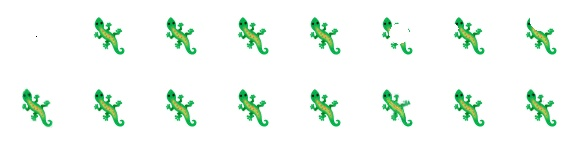

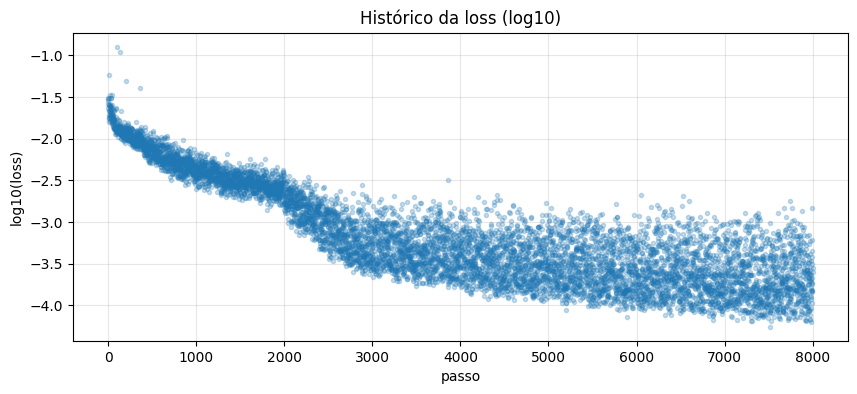

 step: 8001, log10(loss): -3.600
Treinamento concluído.


('train_log/qca_final.weights.h5', 'train_log/qca_final_config.json')

In [ ]:
# ============================================================
# Loop de treinamento
# ============================================================
#
# Este bloco executa o treinamento do Q-NCA.
#
# A cada passo:
# - seleciona um batch de estados;
# - opcionalmente aplica dano em algumas amostras;
# - evolui o autômato por um número aleatório de iterações;
# - calcula a loss em relação ao alvo;
# - atualiza os pesos da rede quaterniônica;
# - salva checkpoints e visualizações periodicamente.
# ============================================================


@tf.function
def train_step(x):
    """
    Executa uma etapa de treinamento do Q-NCA.

    Parâmetros
    ----------
    x : tf.Tensor
        Batch de estados iniciais do autômato.

    -------------
    Funcionamento
    -------------
    Em cada chamada, o autômato é executado por um número aleatório
    de passos entre 64 e 96.

    Isso impede que o modelo aprenda apenas uma dinâmica válida para
    um número fixo de iterações, incentivando maior estabilidade temporal.
    """

    # Sorteia aleatoriamente o número de iterações internas do autômato.
    #
    # O valor é um inteiro no intervalo [64, 96).
    iter_n = tf.random.uniform([], 64, 96, tf.int32)

    # GradientTape registra as operações necessárias para calcular
    # os gradientes da loss em relação aos parâmetros treináveis do modelo.
    with tf.GradientTape() as g:

        # Evolui o autômato por iter_n passos.
        #
        # Cada chamada ca(x) aplica uma atualização celular:
        # - percepção local;
        # - cálculo de dx;
        # - atualização estocástica;
        # - aplicação da máscara de vida.
        for _ in tf.range(iter_n):
            x = ca(x)

        # Calcula a loss média do batch após a evolução.
        #
        # loss_f(x) retorna uma loss por amostra.
        # tf.reduce_mean agrega essas perdas em um único escalar.
        loss = tf.reduce_mean(loss_f(x))

    # Calcula os gradientes da loss em relação às variáveis treináveis
    # do modelo Q-NCA.
    grads = g.gradient(loss, ca.trainable_variables)

    # Normaliza cada gradiente individualmente.
    #
    # Essa estratégia vem do notebook original do Growing NCA.
    # Ela ajuda a reduzir instabilidades, impedindo que uma variável
    # com gradiente muito grande domine a atualização.
    #
    # O termo 1e-8 evita divisão por zero.
    grads = [
        g / (tf.norm(g) + 1e-8) if g is not None else None
        for g in grads
    ]

    # Aplica os gradientes normalizados usando o otimizador Adam.
    trainer.apply_gradients(
        zip(grads, ca.trainable_variables)
    )

    # Retorna o estado evoluído e a loss calculada.
    return x, loss


# ============================================================
# Execução do treinamento
# ============================================================
#
# O loop externo controla o número total de passos de otimização.
#
# TRAIN_STEPS define quantas atualizações de gradiente serão realizadas.
# O +1 permite incluir explicitamente o passo 0 nas visualizações
# e checkpoints.
# ============================================================

for i in range(TRAIN_STEPS + 1):

    # ========================================================
    # Seleção do batch
    # ========================================================

    if USE_PATTERN_POOL:
        # Quando o pattern pool está ativo, o batch é retirado
        # aleatoriamente do pool de estados.
        #
        # Isso permite treinar a partir de estados em diferentes
        # estágios de desenvolvimento.
        batch = pool.sample(BATCH_SIZE)

        # Estados iniciais do batch amostrado.
        x0 = batch.x

        # Calcula a loss de cada amostra do batch e ordena da maior
        # para a menor.
        #
        # A ideia é identificar quais amostras estão piores em relação
        # ao alvo.
        loss_rank = loss_f(x0).numpy().argsort()[::-1]

        # Reordena o batch colocando as amostras com maior loss primeiro.
        x0 = x0[loss_rank]

        # Substitui a pior amostra pela semente inicial.
        #
        # Isso garante que o modelo continue treinando o crescimento
        # desde o início, e não apenas a manutenção/regeneração de padrões
        # já desenvolvidos.
        x0[:1] = seed

        # Se o experimento envolve regeneração, aplica dano artificial
        # nas últimas DAMAGE_N amostras do batch.
        if DAMAGE_N:
            # Cria máscaras circulares aleatórias.
            #
            # make_circle_masks retorna 1 dentro da região circular.
            #
            # Ao fazer 1.0 - máscara, obtemos:
            # - 0 dentro do círculo;
            # - 1 fora do círculo.
            #
            # Multiplicar o estado por essa máscara apaga a região circular.
            damage = 1.0 - make_circle_masks(
                DAMAGE_N,
                h,
                w
            ).numpy()[..., None]

            # Aplica o dano nas últimas amostras do batch.
            x0[-DAMAGE_N:] *= damage

    else:
        # Quando o pattern pool não está ativo, todos os batches começam
        # diretamente da semente inicial.
        #
        # Esse é o regime típico do experimento Growing.
        x0 = np.repeat(
            seed[None, ...],
            BATCH_SIZE,
            axis=0
        )

    # ========================================================
    # Etapa de treinamento
    # ========================================================

    # Converte o batch inicial para tensor TensorFlow e executa uma
    # etapa de treinamento.
    #
    # A função train_step:
    # - evolui o autômato por 64 a 95 passos;
    # - calcula a loss;
    # - calcula os gradientes;
    # - atualiza os pesos do modelo.
    x, loss = train_step(
        tf.convert_to_tensor(x0, dtype=tf.float32)
    )

    # ========================================================
    # Atualização do pattern pool
    # ========================================================

    if USE_PATTERN_POOL:
        # Substitui os estados antigos do batch pelos estados evoluídos.
        batch.x[:] = x.numpy()

        # Escreve os estados atualizados de volta no pool principal.
        batch.commit()

    # ========================================================
    # Registro da loss
    # ========================================================

    # Converte a loss para float Python.
    loss_value = float(loss.numpy())

    # O índice do passo é definido pelo tamanho atual do histórico.
    step_i = len(loss_log)

    # Armazena a loss no histórico.
    loss_log.append(loss_value)

    # ========================================================
    # Visualização periódica do pool
    # ========================================================

    if USE_PATTERN_POOL and step_i % POOL_FIGURE_EVERY == 0:
        # Gera uma imagem mostrando algumas amostras do pool.
        generate_pool_figures(
            pool,
            step_i,
            log_dir=log_dir
        )

    # ========================================================
    # Checkpoints e visualizações periódicas
    # ========================================================

    if step_i % CHECKPOINT_EVERY == 0:
        # Salva os pesos e a configuração do modelo.
        export_model(
            ca,
            f"{log_dir}/qca_{step_i:04d}"
        )

        # Limpa a saída anterior do notebook.
        clear_output()

        # Exibe o passo atual e a loss.
        print(
            f"passo {step_i:05d} | loss={loss_value:.6f}"
        )

        # Mostra o batch antes e depois da evolução.
        visualize_batch(
            tf.convert_to_tensor(x0),
            x,
            step_i,
            log_dir=log_dir
        )

        # Plota o histórico da loss em escala logarítmica.
        plot_loss(loss_log)

    # ========================================================
    # Progresso textual compacto
    # ========================================================

    # Atualiza uma linha de progresso no notebook/terminal.
    print(
        '\r step: %d, log10(loss): %.3f'
        % (len(loss_log), np.log10(loss_value)),
        end=''
    )


# ============================================================
# Finalização do treinamento
# ============================================================

# Mensagem final indicando que o loop terminou.
print("\nTreinamento concluído.")

# Exporta o modelo final treinado.
export_model(
    ca,
    f"{log_dir}/qca_final"
)

# Figuras e animações

As próximas células reproduzem os principais diagnósticos visuais do notebook original, adaptados para o Q-NCA treinado acima.

In [ ]:
# ============================================================
# Visualização do crescimento em diferentes checkpoints
# ============================================================
#
# Este bloco compara o comportamento do Q-NCA em diferentes momentos
# do treinamento.
#
# A ideia é carregar checkpoints salvos em etapas diferentes e gerar
# um vídeo mostrando, lado a lado, como cada versão do modelo consegue
# desenvolver o padrão a partir da mesma semente inicial.
#
# Por exemplo:
# - modelo após 100 passos;
# - modelo após 500 passos;
# - modelo após 1000 passos;
# - modelo após 4000 passos;
# - modelo após 8000 passos.
#
# Isso permite observar visualmente a evolução da capacidade do modelo
# ao longo do treinamento.
# ============================================================

checkpoint_steps = [100, 500, 1000, 4000, 8000]


# Lista que armazenará os modelos carregados.
models = []

# Lista que armazenará os rótulos associados aos modelos.
#
# Neste caso, cada rótulo é simplesmente o número do passo de treinamento
# correspondente ao checkpoint.
labels = []


# ============================================================
# Carregamento dos checkpoints disponíveis
# ============================================================

for step in checkpoint_steps:
    # Monta o caminho esperado para o arquivo de pesos do checkpoint.
    #
    # O formato :04d garante que o número tenha 4 dígitos.
    #
    # Exemplo:
    #   step = 100  -> qca_0100.weights.h5
    #   step = 8000 -> qca_8000.weights.h5
    weights_fn = f"train_log/qca_{step:04d}.weights.h5"

    # Verifica se o arquivo de pesos existe antes de tentar carregá-lo.
    if os.path.exists(weights_fn):

        # Carrega uma nova instância do QCAModel com os pesos salvos.
        m = load_qca_checkpoint(weights_fn)

        # Armazena o modelo carregado.
        models.append(m)

        # Armazena o passo correspondente para referência.
        labels.append(step)


# ============================================================
# Verificação se algum checkpoint foi encontrado
# ============================================================

if not models:
    # Caso nenhum arquivo de checkpoint tenha sido encontrado,
    # o vídeo não pode ser gerado.
    print("Nenhum checkpoint encontrado.")

else:
    # ========================================================
    # Geração do vídeo comparativo
    # ========================================================

    # Nome do arquivo de vídeo de saída.
    #
    # DAMAGE_N é incluído no nome para indicar se o modelo foi treinado
    # com dano/regeneração e quantas amostras danificadas eram usadas.
    out_fn = f"qca_train_steps_damage_{DAMAGE_N}.mp4"

    # Cria uma semente inicial para cada modelo carregado.
    x = make_seed(
        72,
        n=len(models)
    )

    # Cria um escritor de vídeo.
    #
    # O uso com `with` garante que o arquivo seja fechado corretamente
    # ao final da geração.
    with VideoWriter(out_fn) as vid:

        # Executa 500 passos de simulação.
        #
        # Cada passo gera um frame do vídeo.
        for i in tqdm.trange(500):

            # Converte os estados Q-NCA para imagens RGB.
            #
            # to_rgb(x) retorna uma imagem para cada modelo.
            # np.hstack coloca essas imagens lado a lado.
            vis = np.hstack(to_rgb(x))

            # Amplia a visualização por repetição de pixels e adiciona
            # o frame ao vídeo.
            vid.add(
                zoom(vis, 2)
            )

            # Atualiza separadamente o estado de cada modelo.
            #
            # zip(models, x) associa:
            # - um checkpoint carregado;
            # - a respectiva semente/estado no batch x.
            for model, xk in zip(models, x):

                # model espera entrada com dimensão de batch.
                #
                # xk possui shape:
                #     [height, width, CHANNEL_N]
                #
                # xk[None, ...] adiciona dimensão de batch:
                #     [1, height, width, CHANNEL_N]
                #
                # O resultado [0] remove novamente essa dimensão.
                xk[:] = model(xk[None, ...])[0]

    # Exibe o vídeo gerado diretamente no Jupyter Notebook.
    mvp.ipython_display(out_fn)

100%|██████████| 500/500 [00:09<00:00, 50.26it/s]


In [ ]:
# Vídeo do progresso dos batches
frames = sorted(glob.glob("train_log/batches_*.jpg"))
if not frames:
    print("Nenhum frame de batch encontrado.")
else:
    out_fn = "qca_batches.mp4"
    mvp.ImageSequenceClip(frames, fps=10.0).write_videofile(out_fn)
    mvp.ipython_display(out_fn)

Moviepy - Building video qca_batches.mp4.
Moviepy - Writing video qca_batches.mp4



Moviepy - Done !
Moviepy - video ready qca_batches.mp4


In [ ]:
# Vídeo do conteúdo da sample pool
frames = sorted(glob.glob("train_log/*_pool.jpg"))[:80]
if not frames:
    print("Nenhum frame de pool encontrado.")
else:
    out_fn = "qca_pool.mp4"
    mvp.ImageSequenceClip(frames, fps=20.0).write_videofile(out_fn)
    mvp.ipython_display(out_fn)

Moviepy - Building video qca_pool.mp4.
Moviepy - Writing video qca_pool.mp4



Moviepy - Done !
Moviepy - video ready qca_pool.mp4


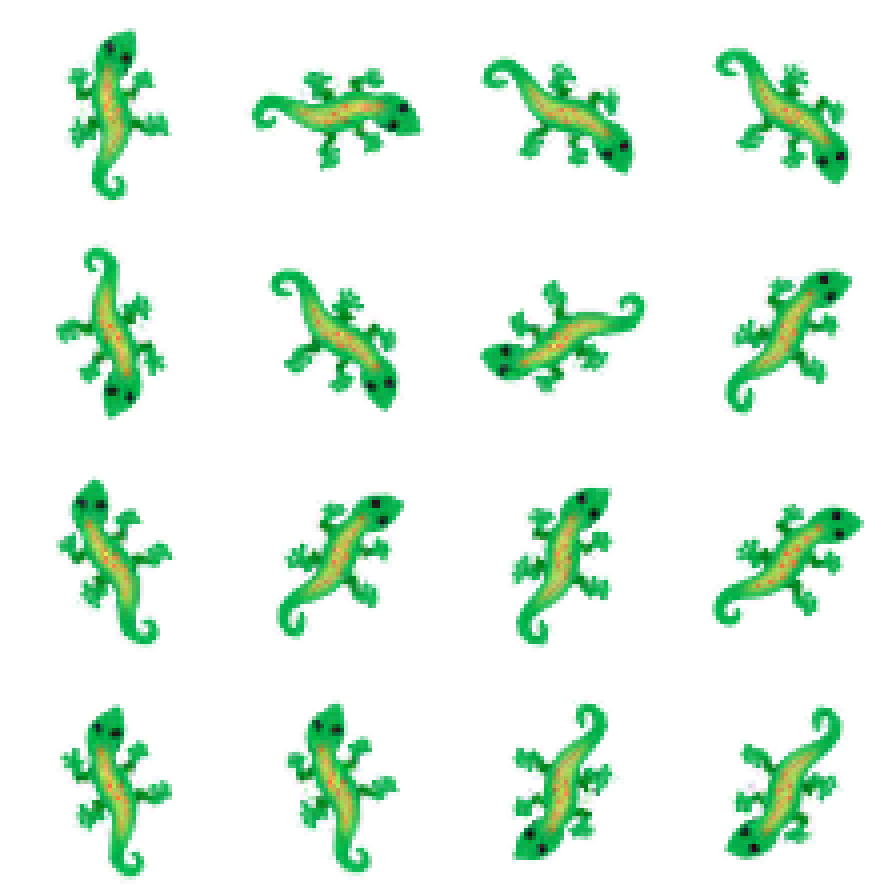

In [ ]:
# ============================================================
# Teste de rotação do campo perceptivo
# ============================================================
#
# Este bloco avalia se a regra aprendida pelo Q-NCA é robusta
# à rotação dos filtros de percepção.
#
# No Neural Cellular Automata original, esse teste é usado para verificar
# se o modelo consegue continuar gerando o padrão mesmo quando os filtros
# de Sobel usados na percepção são rotacionados.
#
# A ideia é:
# - carregar o modelo final treinado;
# - gerar várias sementes independentes;
# - evoluir cada semente usando um ângulo de percepção diferente;
# - visualizar os resultados em uma grade.
#
# Se o modelo for robusto, ele deve conseguir formar o alvo mesmo quando
# sua percepção local estiver rotacionada.
# ============================================================


# Caminho do checkpoint final salvo após o treinamento.
weights_fn = "train_log/qca_final.weights.h5"


# Verifica se o checkpoint final existe antes de tentar carregá-lo.
if not os.path.exists(weights_fn):

    # Caso o arquivo não exista, o teste não pode ser executado.
    print("Checkpoint final não encontrado.")

else:
    # ========================================================
    # Carregamento do modelo treinado
    # ========================================================

    # Carrega uma nova instância do QCAModel com os pesos finais.
    ca_rot = load_qca_checkpoint(weights_fn)


    # ========================================================
    # Configuração da visualização
    # ========================================================

    # Número total de imagens que serão geradas.
    #
    # Cada imagem corresponde a uma simulação do Q-NCA usando
    # um ângulo diferente nos filtros de percepção.
    num_images = 16

    # Número de imagens por linha na visualização final.
    #
    # Com num_images=16 e row_size=4, a saída será uma grade 4x4.
    row_size = 4

    # Lista que armazenará as imagens RGB finais geradas pelo modelo.
    imgs = []

    # Define um ângulo inicial aleatório em graus.
    start_angle = np.random.randint(13, 76)


    # ========================================================
    # Geração das imagens com diferentes ângulos de percepção
    # ========================================================

    for j in range(num_images):

        # Define um ângulo em graus para a imagem atual.
        #
        # A cada imagem, o ângulo é deslocado por um valor aleatório
        # entre 36 e 110 graus.
        #
        # Isso cria uma diversidade de rotações para testar a robustez
        # da regra aprendida.
        ang = start_angle + j * np.random.randint(36, 111)

        # Converte o ângulo de graus para radianos.
        #
        # Fórmula:
        #
        #     radianos = graus / 360 * 2π
        #
        # O método `perceive` do modelo espera o ângulo em radianos.
        ang = ang / 360.0 * 2 * np.pi

        # Cria uma semente inicial em uma grade 56x56.
        #
        # Shape:
        #
        #     [1, 56, 56, CHANNEL_N]
        #
        # O batch possui apenas uma amostra.
        x = make_seed(56, n=1)

        # Evolui o autômato por 500 passos usando o ângulo escolhido.
        #
        # A cada passo, o modelo usa filtros Sobel rotacionados pelo
        # ângulo `ang` durante a etapa de percepção.
        for _ in range(500):
            x = ca_rot(
                x,
                angle=tf.constant(ang, tf.float32)
            )

        # Converte o estado final do Q-NCA para uma imagem RGB
        # visualizável e armazena na lista.
        #
        # to_rgb(x) retorna um batch de imagens.
        # Como n=1, usamos [0] para pegar a única imagem.
        imgs.append(to_rgb(x)[0])


    # ========================================================
    # Montagem da grade de visualização
    # ========================================================

    # Agrupa as imagens em linhas.
    #
    # Cada linha contém `row_size` imagens concatenadas horizontalmente.
    rows = [
        np.hstack(imgs[i:i + row_size])
        for i in range(0, len(imgs), row_size)
    ]

    # Concatena as linhas verticalmente para formar a grade final.
    #
    # Em seguida, amplia a imagem por repetição de pixels para facilitar
    # a visualização no notebook.
    vis = zoom(
        np.vstack(rows),
        4
    )

    # Exibe a visualização final no notebook.
    imshow(vis, fmt="png")

In [ ]:
# ============================================================
# Teste de regeneração com danos estruturados
# ============================================================
#
# Este bloco testa a capacidade regenerativa do Q-NCA treinado.
#
# A ideia é:
# - carregar o checkpoint final do modelo;
# - inicializar várias sementes;
# - deixar o modelo crescer por alguns passos;
# - aplicar danos estruturados em diferentes regiões;
# - continuar a simulação para observar se o modelo reconstrói o padrão.
#
# O resultado é salvo em vídeo no arquivo:
#
#     qca_regeneration.mp4
#
# Esse teste é especialmente relevante para o experimento "Regenerating",
# pois avalia se o autômato aprendeu uma dinâmica capaz de recuperar partes
# removidas da imagem.
# ============================================================


# Caminho do checkpoint final salvo após o treinamento.
weights_fn = "train_log/qca_final.weights.h5"


# Verifica se o checkpoint final existe antes de tentar carregá-lo.
if not os.path.exists(weights_fn):

    # Caso o arquivo não exista, o teste não pode ser executado.
    print("Checkpoint final não encontrado.")

else:
    # ========================================================
    # Carregamento do modelo treinado
    # ========================================================

    # Carrega o modelo Q-NCA a partir dos pesos finais.
    #
    # O modelo carregado será usado apenas para o teste de regeneração.
    ca_regen = load_qca_checkpoint(weights_fn)

    # Nome do arquivo de vídeo que será gerado.
    out_fn = "qca_regeneration.mp4"

    # Cria 5 sementes independentes em uma grade 56x56.
    #
    # Shape:
    #
    #     [5, 56, 56, CHANNEL_N]
    #
    # Cada uma das 5 amostras sofrerá um tipo diferente de dano.
    x = make_seed(56, n=5)

    # Coordenadas aproximadas do centro da grade.
    #
    # Como a grade possui tamanho 56x56:
    #
    #     centro = 56 // 2 = 28
    cx, cy = 28, 28


    # ========================================================
    # Geração do vídeo de regeneração
    # ========================================================

    # Cria o escritor de vídeo.
    #
    # O uso com `with` garante que o arquivo seja finalizado corretamente
    # ao sair do bloco.
    with VideoWriter(out_fn) as vid:

        # Executa a simulação por 1500 passos.
        for i in tqdm.trange(1500):

            # ====================================================
            # Aplicação dos danos estruturados
            # ====================================================
            # Assumindo que o padrão cresceu até i = 200
            if i == 200:

                # Amostra 0:
                # remove a metade inferior da imagem.
                x[0, cy:] = 0

                # Amostra 1:
                # remove a metade superior da imagem.
                x[1, :cy] = 0

                # Amostra 2:
                # remove a metade direita da imagem.
                x[2, :, cx:] = 0

                # Amostra 3:
                # remove a metade esquerda da imagem.
                x[3, :, :cx] = 0

                # Amostra 4:
                # remove uma região quadrada central de tamanho 16x16.
                #
                # Intervalos:
                #
                #     y: cy-8 até cy+8
                #     x: cx-8 até cx+8
                #
                # Como cx = cy = 28, remove a região:
                #
                #     y: 20 até 36
                #     x: 20 até 36
                x[4, cy-8:cy+8, cx-8:cx+8] = 0


            # ====================================================
            # Visualização do estado atual
            # ====================================================

            # Converte o estado Q-NCA para imagens RGB.
            #
            # Como x possui 5 amostras, `to_rgb(x)` retorna 5 imagens.
            vis = to_rgb(x)

            # Organiza as 5 imagens lado a lado.
            vis = np.hstack(vis)

            # Amplia a visualização por repetição de pixels.
            #
            # Isso facilita a visualização no vídeo final.
            vis = zoom(vis, 2)


            # ====================================================
            # Controle de frames salvos no vídeo
            # ====================================================
            #
            # Para evitar um vídeo excessivamente grande, nem todos os
            # passos são salvos como frames.
            #
            # Critério usado:
            #
            # - até o passo 400:
            #     salva um frame a cada 2 passos;
            #
            # - depois do passo 400:
            #     salva um frame a cada 8 passos.
            # ====================================================

            if (i < 400 and i % 2 == 0) or i % 8 == 0:
                vid.add(vis)


            # No instante exato do dano, adiciona vários frames iguais.
            if i == 200:
                for _ in range(29):
                    vid.add(vis)


            # ====================================================
            # Evolução do autômato
            # ====================================================

            # Aplica um passo de atualização do Q-NCA.
            x[:] = ca_regen(x).numpy()


    # Exibe o vídeo gerado diretamente no Jupyter Notebook.
    mvp.ipython_display(out_fn)

100%|██████████| 1500/1500 [00:12<00:00, 119.78it/s]


# Exportação dos pesos reais equivalentes

O notebook original possui uma exportação específica para WebGL/TF.js usando `Conv2D` reais. Aqui, como a camada é quaterniônica, os pesos livres são \(A,B,C,D\), mas a operação pode ser materializada como uma convolução real estruturada.

A função abaixo exporta essa forma real equivalente. Isso é útil para auditoria, reprodução e futura adaptação para TF.js, mas não substitui automaticamente o exportador WebGL do artigo original.

In [ ]:
np.save("loss_32.npy", loss_log32)
np.save("loss_64.npy", loss_log64)
np.save("loss_96.npy", loss_log96)

In [ ]:
loss_original = np.load("loss_original.npy")

In [ ]:
loss_log96 = loss_log

In [ ]:
loss_log64 = loss_log

In [ ]:
loss_log32 = loss_log

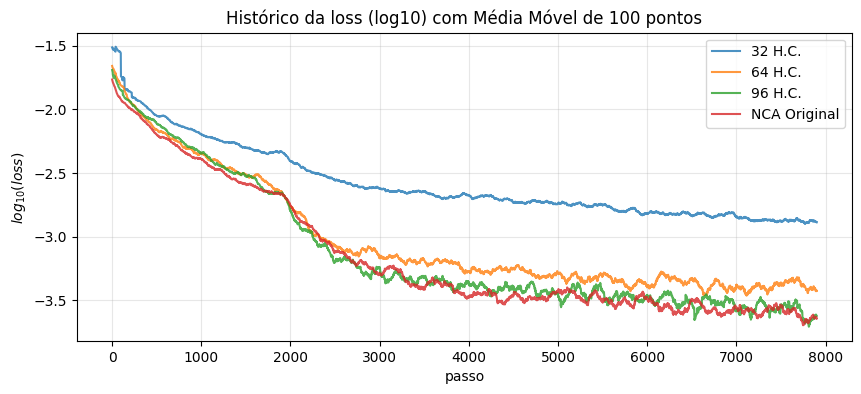

In [ ]:
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

window_size = 100
smoothed_loss_log32 = moving_average(loss_log32, window_size)
smoothed_loss_log64 = moving_average(loss_log64, window_size)
smoothed_loss_log96 = moving_average(loss_log96, window_size)
smoothed_loss_original = moving_average(loss_original, window_size)

plt.figure(figsize=(10, 4))
plt.title(f"Histórico da loss (log10) com Média Móvel de {window_size} pontos")
plt.plot(np.log10(smoothed_loss_log32), alpha=0.8, label='32 H.C.')
plt.plot(np.log10(smoothed_loss_log64), alpha=0.8, label='64 H.C.')
plt.plot(np.log10(smoothed_loss_log96), alpha=0.8, label='96 H.C.')
plt.plot(np.log10(smoothed_loss_original), alpha=0.8, label='NCA Original')
plt.xlabel("passo")
plt.ylabel("$log_{10}(loss)$ ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()